In [ ]:
# 0) INSTALLATION / IMPORTS

import os
import re
import cv2
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
# 1) GOOGLE COLAB : MONTER GOOGLE DRIVE

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive monté avec succès.")
except Exception as e:
    print("Pas dans Google Colab ou Drive déjà monté. Détail :", e)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive monté avec succès.


## 2) Configuration du chemin du dataset

In [ ]:
# 2) CONFIGURATION DES CHEMINS

DATASET_DIR = Path('/content/drive/MyDrive/AD')  # <<< A MODIFIER

# Structure donnée par l'utilisateur
TRAIN_COLOR_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'color'
TRAIN_DEPTH_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'depth'
TEST_COLOR_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'color'
TEST_DEPTH_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'depth'

# Choix de la modalité : 'color', 'depth', ou 'color_depth'
MODALITY = 'color'

# Taille des images pour l'ACP
IMG_SIZE = (64, 64)

# Nombre maximum d'images à utiliser pour aller vite dans Colab.
# Mets None pour utiliser tout le dataset.
MAX_TRAIN_IMAGES = None
MAX_TEST_IMAGES = None

# Taux d'inertie souhaité pour choisir le nombre de composantes principales
VARIANCE_TO_KEEP = 0.90
MAX_PCA_COMPONENTS = 150

print('DATASET_DIR =', DATASET_DIR)
for name, p in {
    'TRAIN_COLOR_DIR': TRAIN_COLOR_DIR,
    'TRAIN_DEPTH_DIR': TRAIN_DEPTH_DIR,
    'TEST_COLOR_DIR': TEST_COLOR_DIR,
    'TEST_DEPTH_DIR': TEST_DEPTH_DIR,
}.items():
    print(f'{name:16s}: {p} -> existe = {p.exists()}')

# Améliorations demandées après les tests externes
# Objectif : rester dans le cadre ACP, mais réduire les faux Fake sur des images Real externes.
USE_CLAHE_FOR_ALL_IMAGES = True          # même amélioration de contraste pour train/test/upload/caméra
USE_CLASS_WEIGHT_BALANCED = True         # SVM équilibré pour éviter un biais vers Fake
USE_BEST_AXES_FOR_CLASSIFICATION = True  # comparer plusieurs nombres d'axes ACP sur validation
AXES_CANDIDATES = [20, 40, 59, 80, 100, 120, 150]
EXTERNAL_CONFIDENCE_THRESHOLD = 0.70     # si proba max < 70%, afficher Incertain au lieu de Real/Fake
# Calibration du seuil Real/Fake pour réduire le problème : vraies images prédites Fake
# Le seuil par défaut 0.50 peut être trop strict pour Real.
CALIBRATE_REAL_THRESHOLD = True
REAL_THRESHOLD_MIN = 0.20
REAL_THRESHOLD_MAX = 0.80
REAL_THRESHOLD_STEP = 0.01
# Objectif : garder un bon équilibre, mais pénaliser les Real classés Fake.
REAL_RECALL_PRIORITY = 0.15
BEST_REAL_THRESHOLD_FALLBACK = 0.35
EXTERNAL_VARIANT_MODE = 'face_priority'  # 'face_priority' = crop visage + contraste uniquement
# Décision externe plus prudente et plus ACP-compatible
EXTERNAL_REAL_THRESHOLD_DEFAULT = 0.35    # seuil Real moins strict pour éviter Real -> Fake
EXTERNAL_FAKE_STRONG_THRESHOLD = 0.85     # Fake seulement si très sûr
EXTERNAL_UNCERTAINTY_MARGIN = 0.15        # zone d'incertitude entre Real et Fake
EXTERNAL_DISTANCE_PERCENTILE = 97.5       # rejet ACP si image trop loin du nuage d'apprentissage
USE_ACP_DISTANCE_REJECTION = True         # si True : image éloignée => Incertain



# ============================================================
# OPTIONS D'ACCÉLÉRATION GOOGLE COLAB
# ============================================================
# Le GPU n'accélère pas beaucoup la lecture des images / OpenCV / sklearn.
# Les deux vraies accélérations sont :
# 1) copier le dataset de Drive vers /content ;
# 2) sauvegarder X_train / X_test dans un cache .npz.

USE_LOCAL_DATASET_COPY = True       # copie DATASET_DIR vers /content pour éviter la lenteur Drive
REBUILD_LOCAL_COPY = False          # True = recopier même si le dossier local existe déjà
LOCAL_DATASET_DIR = Path('/content/CASIA_ACP_DATASET_LOCAL')

USE_MATRIX_CACHE = True             # sauvegarde/charge directement X_train, y_train, X_test, y_test
REBUILD_MATRIX_CACHE = False        # True = forcer la reconstruction depuis les images
CACHE_DIR_LOCAL = Path('/content/ACP_CACHE_LOCAL')
CACHE_DIR_DRIVE = Path('/content/drive/MyDrive/ACP_CACHE_ANAD')
SAVE_CACHE_TO_DRIVE = True          # utile pour la prochaine session Colab
LOAD_CACHE_FROM_DRIVE = True

# Mode rapide pour vérifier le code sans tout charger.
# Pour le rendu final, laisse FAST_MODE = False.
FAST_MODE = False
FAST_MAX_TRAIN = 800
FAST_MAX_TEST = 500

if FAST_MODE:
    MAX_TRAIN_IMAGES = FAST_MAX_TRAIN
    MAX_TEST_IMAGES = FAST_MAX_TEST
    MAX_PCA_COMPONENTS = min(MAX_PCA_COMPONENTS, 80)
    AXES_CANDIDATES = [20, 40, 59, 80]
    print('FAST_MODE activé : chargement limité pour tester rapidement.')


DATASET_DIR = /content/drive/MyDrive/AD
TRAIN_COLOR_DIR : /content/drive/MyDrive/AD/train_img/train_img/color -> existe = True
TRAIN_DEPTH_DIR : /content/drive/MyDrive/AD/train_img/train_img/depth -> existe = True
TEST_COLOR_DIR  : /content/drive/MyDrive/AD/test_img/test_img/color -> existe = True
TEST_DEPTH_DIR  : /content/drive/MyDrive/AD/test_img/test_img/depth -> existe = True


In [ ]:
# 2 bis) ACCÉLÉRATION COLAB : COPIE LOCALE DU DATASET

import time
import shutil
import hashlib


def refresh_dataset_paths():
    """Recalcule les sous-dossiers train/test après changement de DATASET_DIR."""
    global TRAIN_COLOR_DIR, TRAIN_DEPTH_DIR, TEST_COLOR_DIR, TEST_DEPTH_DIR
    TRAIN_COLOR_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'color'
    TRAIN_DEPTH_DIR = DATASET_DIR / 'train_img' / 'train_img' / 'depth'
    TEST_COLOR_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'color'
    TEST_DEPTH_DIR  = DATASET_DIR / 'test_img'  / 'test_img'  / 'depth'


def copy_dataset_to_content_if_needed():
    """Copie DATASET_DIR vers /content si demandé."""
    global DATASET_DIR

    if not USE_LOCAL_DATASET_COPY:
        print('Copie locale désactivée. DATASET_DIR reste :', DATASET_DIR)
        return

    original = Path(DATASET_DIR)
    local = Path(LOCAL_DATASET_DIR)

    if not original.exists():
        print('DATASET_DIR introuvable, copie impossible :', original)
        return

    # Si le dataset est déjà dans /content, inutile de copier.
    if str(original).startswith('/content/') and not str(original).startswith('/content/drive'):
        print('Dataset déjà local dans /content :', original)
        return

    start = time.time()
    if local.exists() and REBUILD_LOCAL_COPY:
        print('Suppression ancienne copie locale...')
        shutil.rmtree(local)

    if not local.exists():
        print('Copie du dataset vers /content. Cette étape peut prendre du temps une seule fois...')
        shutil.copytree(original, local)
    else:
        print('Copie locale déjà disponible :', local)

    DATASET_DIR = local
    refresh_dataset_paths()
    print('DATASET_DIR utilisé maintenant :', DATASET_DIR)
    print('Temps copie/vérification :', round(time.time() - start, 2), 'secondes')


copy_dataset_to_content_if_needed()

print('\nVérification des chemins après accélération :')
for name, p in {
    'TRAIN_COLOR_DIR': TRAIN_COLOR_DIR,
    'TRAIN_DEPTH_DIR': TRAIN_DEPTH_DIR,
    'TEST_COLOR_DIR': TEST_COLOR_DIR,
    'TEST_DEPTH_DIR': TEST_DEPTH_DIR,
}.items():
    print(f'{name:16s}: {p} -> existe = {p.exists()}')

# Création des dossiers cache
CACHE_DIR_LOCAL.mkdir(parents=True, exist_ok=True)
try:
    CACHE_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
except Exception as e:
    print('Cache Drive non créé pour le moment :', e)


Copie locale déjà disponible : /content/CASIA_ACP_DATASET_LOCAL
DATASET_DIR utilisé maintenant : /content/CASIA_ACP_DATASET_LOCAL
Temps copie/vérification : 0.0 secondes

Vérification des chemins après accélération :
TRAIN_COLOR_DIR : /content/CASIA_ACP_DATASET_LOCAL/train_img/train_img/color -> existe = True
TRAIN_DEPTH_DIR : /content/CASIA_ACP_DATASET_LOCAL/train_img/train_img/depth -> existe = True
TEST_COLOR_DIR  : /content/CASIA_ACP_DATASET_LOCAL/test_img/test_img/color -> existe = True
TEST_DEPTH_DIR  : /content/CASIA_ACP_DATASET_LOCAL/test_img/test_img/depth -> existe = True


In [ ]:
# 3) UTILITAIRES : LISTE DES IMAGES ET AFFICHAGE

IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']

def list_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    paths = [p for p in folder.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS]
    return sorted(paths)

def limit_paths(paths, max_images=None):
    if max_images is None or len(paths) <= max_images:
        return paths
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(paths), size=max_images, replace=False)
    return [paths[i] for i in sorted(idx)]

train_color_paths = limit_paths(list_images(TRAIN_COLOR_DIR), MAX_TRAIN_IMAGES)
test_color_paths  = limit_paths(list_images(TEST_COLOR_DIR), MAX_TEST_IMAGES)

print('Nombre images train/color :', len(train_color_paths))
print('Nombre images test/color  :', len(test_color_paths))
print('Exemples train :')
for p in train_color_paths[:5]:
    print(' -', p)


Nombre images train/color : 1655
Nombre images test/color  : 2408
Exemples train :
 - /content/CASIA_ACP_DATASET_LOCAL/train_img/train_img/color/10_1.avi_100_real.jpg
 - /content/CASIA_ACP_DATASET_LOCAL/train_img/train_img/color/10_1.avi_25_real.jpg
 - /content/CASIA_ACP_DATASET_LOCAL/train_img/train_img/color/10_1.avi_50_real.jpg
 - /content/CASIA_ACP_DATASET_LOCAL/train_img/train_img/color/10_1.avi_75_real.jpg
 - /content/CASIA_ACP_DATASET_LOCAL/train_img/train_img/color/10_2.avi_100_real.jpg


In [ ]:
# 4) RECHERCHE AUTOMATIQUE DES FICHIERS LABELS

def find_label_files(root):
    root = Path(root)
    candidates = []
    if not root.exists():
        return []
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in ['.txt', '.csv', '.tsv', '.json']:
            name = p.name.lower()
            if any(k in name for k in ['label', 'list', 'train', 'test', 'protocol', 'groundtruth', 'gt']):
                candidates.append(p)
    return sorted(candidates)

label_files = find_label_files(DATASET_DIR)
print('Fichiers labels/listes trouvés :')
for p in label_files:
    print(' -', p)

if len(label_files) == 0:
    print("\nAucun fichier label trouvé automatiquement.")
    print("Il faut chercher dans ton dataset un fichier comme train_label.txt, train_list.txt, label.csv, etc.")


Fichiers labels/listes trouvés :

Aucun fichier label trouvé automatiquement.
Il faut chercher dans ton dataset un fichier comme train_label.txt, train_list.txt, label.csv, etc.


In [ ]:
# 5) LECTURE ROBUSTE DES LABELS

# Le code accepte plusieurs formats :
# image.jpg 1
# image.jpg 0
# train_img/color/image.jpg,real
# train_img/color/image.jpg,fake
# etc.
# Par défaut : 1 = real et 0 = fake. Change LABEL_MAP si ton dataset utilise l'inverse.

LABEL_MAP = {
    '1': 1, 'real': 1, 'live': 1, 'genuine': 1, 'true': 1,
    '0': 0, 'fake': 0, 'spoof': 0, 'attack': 0, 'false': 0, 'print': 0, 'replay': 0, 'mask': 0,
}
CLASS_NAMES = {0: 'Fake', 1: 'Real'}

def normalize_key(s):
    s = str(s).strip()
    s = s.replace('\\', '/')
    return s.lower()

def keys_for_path(path, root=None):
    path = Path(path)
    keys = set()
    keys.add(normalize_key(path.name))
    keys.add(normalize_key(path.stem))
    keys.add(normalize_key(str(path)))
    if root is not None:
        try:
            keys.add(normalize_key(str(path.relative_to(root))))
        except Exception:
            pass
    # clés utiles si le label file donne seulement color/xxx.png
    parts = list(path.parts)
    for i in range(len(parts)):
        keys.add(normalize_key('/'.join(parts[i:])))
    return keys

def parse_label_token(token):
    t = str(token).strip().lower()
    t = t.replace(',', '').replace(';', '')
    if t in LABEL_MAP:
        return LABEL_MAP[t]
    # accepte des tokens comme label=1 ou spoof_type=0
    m = re.search(r'[-+]?\d+', t)
    if m:
        val = m.group(0)
        if val in LABEL_MAP:
            return LABEL_MAP[val]
    return None

def read_label_file(label_path):
    label_path = Path(label_path)
    label_dict = {}
    if not label_path.exists():
        raise FileNotFoundError(label_path)

    if label_path.suffix.lower() == '.json':
        data = json.load(open(label_path, 'r', encoding='utf-8'))
        if isinstance(data, dict):
            iterable = data.items()
        else:
            iterable = []
        for k, v in iterable:
            lab = parse_label_token(v)
            if lab is not None:
                label_dict[normalize_key(k)] = lab
                label_dict[normalize_key(Path(str(k)).name)] = lab
        return label_dict

    # CSV/TSV/TXT : lecture souple ligne par ligne
    with open(label_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line or line.startswith('#'):
            continue

        # séparateurs courants
        parts = re.split(r'[\s,;]+', line)
        parts = [p for p in parts if p != '']
        if len(parts) < 2:
            continue

        # On cherche un token qui ressemble à une image/chemin
        path_token = None
        for token in parts:
            tok = token.lower()
            if any(ext in tok for ext in IMAGE_EXTENSIONS) or '/' in tok or '\\' in tok:
                path_token = token
                break
        if path_token is None:
            path_token = parts[0]

        # On cherche le label : souvent dernier token
        lab = None
        for token in reversed(parts):
            lab = parse_label_token(token)
            if lab is not None:
                break

        if lab is None:
            continue

        label_dict[normalize_key(path_token)] = lab
        label_dict[normalize_key(Path(path_token).name)] = lab
        label_dict[normalize_key(Path(path_token).stem)] = lab

    return label_dict

def merge_label_files(files):
    merged = {}
    for lf in files:
        try:
            d = read_label_file(lf)
            print(f'{lf.name}: {len(d)} labels lus')
            merged.update(d)
        except Exception as e:
            print('Impossible de lire', lf, '->', e)
    return merged

label_dict_all = merge_label_files(label_files)
print('\nTotal labels utilisables :', len(label_dict_all))
print('Exemples labels :', list(label_dict_all.items())[:10])



Total labels utilisables : 0
Exemples labels : []


In [ ]:
# 6) SI PAS DE LABEL FILE : TENTATIVE D'INFÉRENCE PAR NOM

def infer_label_from_path(path):
    s = normalize_key(str(path))
    fake_keywords = ['fake', 'spoof', 'attack', 'replay', 'print', 'photo', 'mask']
    real_keywords = ['real', 'live', 'genuine']
    if any(k in s for k in fake_keywords):
        return 0
    if any(k in s for k in real_keywords):
        return 1
    return None

def get_label_for_path(path, label_dict, root=None):
    for k in keys_for_path(path, root=root):
        if k in label_dict:
            return label_dict[k]
    return infer_label_from_path(path)

# Test rapide sur les premières images
print('Test association label sur quelques images :')
for p in train_color_paths[:10]:
    print(p.name, '->', get_label_for_path(p, label_dict_all, DATASET_DIR))


Test association label sur quelques images :
10_1.avi_100_real.jpg -> 1
10_1.avi_25_real.jpg -> 1
10_1.avi_50_real.jpg -> 1
10_1.avi_75_real.jpg -> 1
10_2.avi_100_real.jpg -> 1
10_2.avi_125_real.jpg -> 1
10_2.avi_25_real.jpg -> 1
10_2.avi_50_real.jpg -> 1
10_2.avi_75_real.jpg -> 1
10_3.avi_25_fake.jpg -> 0


In [ ]:
# 7) PRÉTRAITEMENT IMAGE : COLOR / DEPTH / COLOR_DEPTH#


def cv2_read_image(path, flags=cv2.IMREAD_COLOR):
    """Lecture robuste d'une image avec OpenCV, même si le nom contient des espaces/accents."""
    path = str(path)
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, flags)
    if img is None:
        img = cv2.imread(path, flags)
    return img


def apply_clahe_uint8(gray_u8):
    """Amélioration légère du contraste, appliquée de façon identique si activée."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_u8)


def read_gray_resized(path, img_size=IMG_SIZE, use_clahe=USE_CLAHE_FOR_ALL_IMAGES):
    img = cv2_read_image(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    if use_clahe:
        img = apply_clahe_uint8(img)
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img


def find_matching_depth_path(color_path, color_root, depth_root):
    color_path = Path(color_path)
    try:
        rel = color_path.relative_to(color_root)
        candidate = depth_root / rel
        if candidate.exists():
            return candidate
    except Exception:
        pass

    # fallback : même nom dans depth
    matches = list(Path(depth_root).rglob(color_path.name)) if Path(depth_root).exists() else []
    if matches:
        return matches[0]
    return None


def preprocess_sample(color_path, modality='color', img_size=IMG_SIZE, color_root=None, depth_root=None):
    if modality == 'color':
        img = read_gray_resized(color_path, img_size)
        if img is None:
            return None
        return img.flatten()

    if modality == 'depth':
        depth_path = find_matching_depth_path(color_path, color_root, depth_root)
        if depth_path is None:
            return None
        img = read_gray_resized(depth_path, img_size)
        if img is None:
            return None
        return img.flatten()

    if modality == 'color_depth':
        img_c = read_gray_resized(color_path, img_size)
        depth_path = find_matching_depth_path(color_path, color_root, depth_root)
        img_d = read_gray_resized(depth_path, img_size) if depth_path is not None else None
        if img_c is None or img_d is None:
            return None
        return np.concatenate([img_c.flatten(), img_d.flatten()])

    raise ValueError("MODALITY doit être 'color', 'depth', ou 'color_depth'")


def load_dataset_from_color_paths(color_paths, color_root, depth_root, label_dict, dataset_root, require_labels=True, desc='Chargement'):
    X, y, paths_kept = [], [], []
    missing_labels = 0
    skipped_images = 0

    for p in tqdm(color_paths, desc=desc):
        lab = get_label_for_path(p, label_dict, root=dataset_root)
        if lab is None and require_labels:
            missing_labels += 1
            continue

        vec = preprocess_sample(p, modality=MODALITY, img_size=IMG_SIZE, color_root=color_root, depth_root=depth_root)
        if vec is None:
            skipped_images += 1
            continue

        X.append(vec)
        if lab is not None:
            y.append(lab)
        paths_kept.append(p)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=int) if len(y) > 0 else None

    print(f'{desc}: X={X.shape}, y={None if y is None else y.shape}')
    print('Images ignorées sans label :', missing_labels)
    print('Images illisibles / depth manquant :', skipped_images)
    return X, y, paths_kept



# 7 bis) CHARGEMENT ACCÉLÉRÉ AVEC CACHE DES MATRICES X/y


def make_cache_signature():
    """Signature simple pour éviter de mélanger différents réglages."""
    # On garde une signature basée sur les paramètres importants et le nombre de chemins.
    raw = "|".join([
        str(MODALITY), str(IMG_SIZE), str(USE_CLAHE_FOR_ALL_IMAGES),
        str(MAX_TRAIN_IMAGES), str(MAX_TEST_IMAGES),
        str(len(train_color_paths)), str(len(test_color_paths)),
        str(train_color_paths[0].name if len(train_color_paths) else 'no_train'),
        str(test_color_paths[0].name if len(test_color_paths) else 'no_test'),
    ])
    return hashlib.md5(raw.encode('utf-8')).hexdigest()[:12]

CACHE_SIGNATURE = make_cache_signature()
CACHE_FILE_NAME = f'matrices_acp_{MODALITY}_{IMG_SIZE[0]}x{IMG_SIZE[1]}_clahe{int(USE_CLAHE_FOR_ALL_IMAGES)}_{CACHE_SIGNATURE}.npz'
CACHE_FILE_LOCAL = CACHE_DIR_LOCAL / CACHE_FILE_NAME
CACHE_FILE_DRIVE = CACHE_DIR_DRIVE / CACHE_FILE_NAME

print('Fichier cache local :', CACHE_FILE_LOCAL)
print('Fichier cache Drive :', CACHE_FILE_DRIVE)


def save_matrices_cache():
    """Sauvegarde X/y + chemins dans le cache local et éventuellement Drive."""
    y_test_is_none = y_test_raw is None
    y_test_to_save = np.array([], dtype=int) if y_test_raw is None else y_test_raw

    payload = dict(
        X_train_raw=X_train_raw,
        y_train_raw=y_train_raw,
        train_paths=np.array([str(p) for p in train_paths_kept], dtype=object),
        X_test_raw=X_test_raw,
        y_test_raw=y_test_to_save,
        y_test_is_none=np.array([y_test_is_none]),
        test_paths=np.array([str(p) for p in test_paths_kept], dtype=object),
        modality=np.array([MODALITY], dtype=object),
        img_size=np.array(IMG_SIZE),
        use_clahe=np.array([USE_CLAHE_FOR_ALL_IMAGES]),
    )

    np.savez_compressed(CACHE_FILE_LOCAL, **payload)
    print('Cache local sauvegardé :', CACHE_FILE_LOCAL)

    if SAVE_CACHE_TO_DRIVE:
        try:
            CACHE_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
            shutil.copy2(CACHE_FILE_LOCAL, CACHE_FILE_DRIVE)
            print('Cache Drive sauvegardé :', CACHE_FILE_DRIVE)
        except Exception as e:
            print('Impossible de sauvegarder le cache Drive :', e)


def load_matrices_cache():
    """Charge les matrices depuis le cache local ou Drive."""
    global X_train_raw, y_train_raw, train_paths_kept, X_test_raw, y_test_raw, test_paths_kept

    candidates = []
    if CACHE_FILE_LOCAL.exists():
        candidates.append(CACHE_FILE_LOCAL)
    if LOAD_CACHE_FROM_DRIVE and CACHE_FILE_DRIVE.exists():
        candidates.append(CACHE_FILE_DRIVE)

    if len(candidates) == 0 or REBUILD_MATRIX_CACHE:
        return False

    cache_file = candidates[0]
    print('Chargement des matrices depuis le cache :', cache_file)
    data = np.load(cache_file, allow_pickle=True)

    X_train_raw = data['X_train_raw']
    y_train_raw = data['y_train_raw']
    train_paths_kept = [Path(s) for s in data['train_paths'].tolist()]
    X_test_raw = data['X_test_raw']
    y_test_is_none = bool(data['y_test_is_none'][0])
    y_test_raw = None if y_test_is_none else data['y_test_raw']
    test_paths_kept = [Path(s) for s in data['test_paths'].tolist()]

    # Si on a chargé depuis Drive, on le recopie aussi localement pour accélérer la suite.
    if cache_file == CACHE_FILE_DRIVE and not CACHE_FILE_LOCAL.exists():
        try:
            shutil.copy2(CACHE_FILE_DRIVE, CACHE_FILE_LOCAL)
        except Exception:
            pass

    print('Cache chargé avec succès.')
    print('X_train_raw =', X_train_raw.shape, '| y_train_raw =', y_train_raw.shape)
    print('X_test_raw  =', X_test_raw.shape,  '| y_test_raw  =', None if y_test_raw is None else y_test_raw.shape)
    return True


if USE_MATRIX_CACHE and load_matrices_cache():
    print('Lecture des images évitée grâce au cache.')
else:
    print('Cache absent ou reconstruction forcée : lecture des images...')
    X_train_raw, y_train_raw, train_paths_kept = load_dataset_from_color_paths(
        train_color_paths, TRAIN_COLOR_DIR, TRAIN_DEPTH_DIR, label_dict_all, DATASET_DIR,
        require_labels=True, desc='Train'
    )

    # Pour le test : on charge avec labels si disponibles ; sinon on charge quand même pour prédiction seulement.
    X_test_raw, y_test_raw, test_paths_kept = load_dataset_from_color_paths(
        test_color_paths, TEST_COLOR_DIR, TEST_DEPTH_DIR, label_dict_all, DATASET_DIR,
        require_labels=False, desc='Test'
    )

    if USE_MATRIX_CACHE:
        save_matrices_cache()

if X_train_raw.shape[0] == 0 or y_train_raw is None or len(np.unique(y_train_raw)) < 2:
    raise ValueError("""
Aucun entraînement possible : les labels Real/Fake ne sont pas trouvés ou une seule classe est détectée.
Solution : vérifie le fichier de labels du dataset. Il doit contenir le chemin/nom de l'image et son label.
Exemple : image_001.jpg 1 ; image_002.jpg 0, avec 1=Real et 0=Fake.
""")

print('\nDistribution train :')
print(pd.Series(y_train_raw).map(CLASS_NAMES).value_counts())
if y_test_raw is not None and len(y_test_raw) > 0 and len(y_test_raw) == X_test_raw.shape[0]:
    print('\nDistribution test :')
    print(pd.Series(y_test_raw).map(CLASS_NAMES).value_counts())
else:
    print('\nLabels test absents ou incomplets : le test officiel sera utilisé seulement comme prédiction externe si nécessaire.')


Fichier cache local : /content/ACP_CACHE_LOCAL/matrices_acp_color_64x64_clahe1_a8635d430a4a.npz
Fichier cache Drive : /content/drive/MyDrive/ACP_CACHE_ANAD/matrices_acp_color_64x64_clahe1_a8635d430a4a.npz
Chargement des matrices depuis le cache : /content/ACP_CACHE_LOCAL/matrices_acp_color_64x64_clahe1_a8635d430a4a.npz
Cache chargé avec succès.
X_train_raw = (1655, 4096) | y_train_raw = (1655,)
X_test_raw  = (2408, 4096) | y_test_raw  = (2408,)
Lecture des images évitée grâce au cache.

Distribution train :
Fake    1251
Real     404
Name: count, dtype: int64

Distribution test :
Fake    1817
Real     591
Name: count, dtype: int64


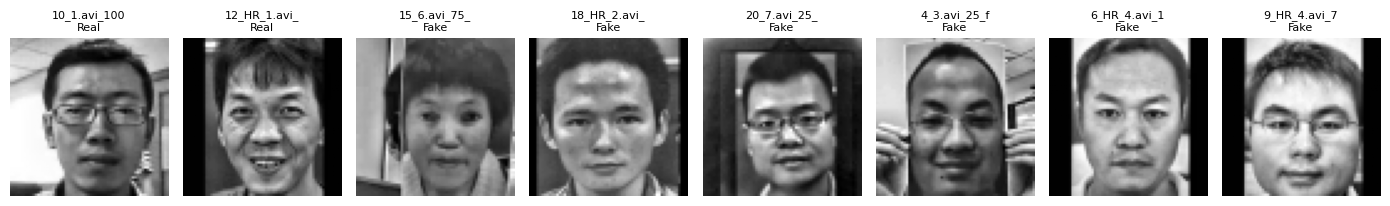

In [ ]:


def show_samples(paths, labels=None, n=8):
    if len(paths) == 0:
        print('Aucune image à afficher.')
        return
    n = min(n, len(paths))
    idx = np.linspace(0, len(paths)-1, n, dtype=int)
    plt.figure(figsize=(14, 3))
    for j, i in enumerate(idx):
        img = read_gray_resized(paths[i], IMG_SIZE)
        plt.subplot(1, n, j+1)
        plt.imshow(img, cmap='gray')
        title = paths[i].name[:12]
        if labels is not None and len(labels) > i:
            title += f"\n{CLASS_NAMES[int(labels[i])]}"
        plt.title(title, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_paths_kept, y_train_raw, n=8)


In [38]:
# ============================================================
# 9) MATRICE DES DONNÉES X + NORMALISATION Z
# ============================================================
# Dans le vocabulaire du cours :
# - les individus = images/frames de visage
# - les variables = pixels
# - X = matrice des données
# - Z = matrice centrée-réduite

X = X_train_raw
y = y_train_raw

print('Matrice X :', X.shape)
print("Nombre d'individus/images m =", X.shape[0])
print('Nombre de variables/pixels n =', X.shape[1])

# Quelques statistiques comme TP1
mean_vector = X.mean(axis=0)
var_vector = X.var(axis=0)
std_vector = X.std(axis=0)
print('Moyenne globale des pixels :', X.mean())
print('Variance globale des pixels :', X.var())

scaler = StandardScaler(with_mean=True, with_std=True)
Z = scaler.fit_transform(X)
print('Matrice centrée-réduite Z :', Z.shape)


Matrice X : (1655, 4096)
Nombre d'individus/images m = 1655
Nombre de variables/pixels n = 4096
Moyenne globale des pixels : 0.41749224
Variance globale des pixels : 0.05888827
Matrice centrée-réduite Z : (1655, 4096)


In [ ]:
# ============================================================
# 10) SPLIT VALIDATION OU TEST OFFICIEL
# ============================================================
# Si le test a des labels, on évaluera aussi sur test.
# Sinon on fait une validation interne à partir du train.

X_tr, X_val, y_tr, y_val, paths_tr, paths_val = train_test_split(
    X, y, train_paths_kept, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

scaler_model = StandardScaler(with_mean=True, with_std=True)
Z_tr = scaler_model.fit_transform(X_tr)
Z_val = scaler_model.transform(X_val)

print('Train interne :', Z_tr.shape, pd.Series(y_tr).map(CLASS_NAMES).value_counts().to_dict())
print('Validation interne :', Z_val.shape, pd.Series(y_val).map(CLASS_NAMES).value_counts().to_dict())


Train interne : (1241, 4096) {'Fake': 938, 'Real': 303}
Validation interne : (414, 4096) {'Fake': 313, 'Real': 101}


In [40]:
# ============================================================
# 11) ACP NORMÉE : VALEURS PROPRES, INERTIE, AXES
# ============================================================
# On applique l'ACP sur Z_tr.
# Les valeurs propres correspondent à l'inertie portée par les axes.

max_comp = min(MAX_PCA_COMPONENTS, Z_tr.shape[0] - 1, Z_tr.shape[1])
if max_comp < 2:
    raise ValueError('Pas assez de données pour faire une ACP avec au moins 2 composantes.')

pca_full = PCA(n_components=max_comp, svd_solver='randomized', random_state=RANDOM_STATE)
C_tr_full = pca_full.fit_transform(Z_tr)
C_val_full = pca_full.transform(Z_val)

eigenvalues = pca_full.explained_variance_
inertia_ratio = pca_full.explained_variance_ratio_
cum_inertia = np.cumsum(inertia_ratio)

if cum_inertia[-1] >= VARIANCE_TO_KEEP:
    n_selected = int(np.searchsorted(cum_inertia, VARIANCE_TO_KEEP) + 1)
else:
    n_selected = max_comp

print('Nombre max de composantes calculées :', max_comp)
print(f'Nombre de composantes retenues pour {VARIANCE_TO_KEEP*100:.0f}% inertie :', n_selected)
print('Inertie cumulée retenue :', cum_inertia[n_selected-1])

acp_table = pd.DataFrame({
    'Axe': [f'F{i+1}' for i in range(len(eigenvalues))],
    'Valeur propre': eigenvalues,
    'Taux inertie (%)': inertia_ratio * 100,
    'Inertie cumulée (%)': cum_inertia * 100,
})
acp_table.head(15)


Nombre max de composantes calculées : 150
Nombre de composantes retenues pour 90% inertie : 115
Inertie cumulée retenue : 0.90010506


,Axe,Valeur propre,Taux inertie (%),Inertie cumulée (%)
0,F1,796.053833,19.419243,19.419243
1,F2,464.367554,11.327960,30.747202
2,F3,281.151245,6.858511,37.605713
3,F4,189.804718,4.630169,42.235886
4,F5,142.567978,3.477858,45.713741
5,F6,119.855934,2.923812,48.637550
6,F7,97.452469,2.377293,51.014847
7,F8,84.032318,2.049917,53.064762
8,F9,79.075279,1.928993,54.993755
9,F10,73.045097,1.781890,56.775646


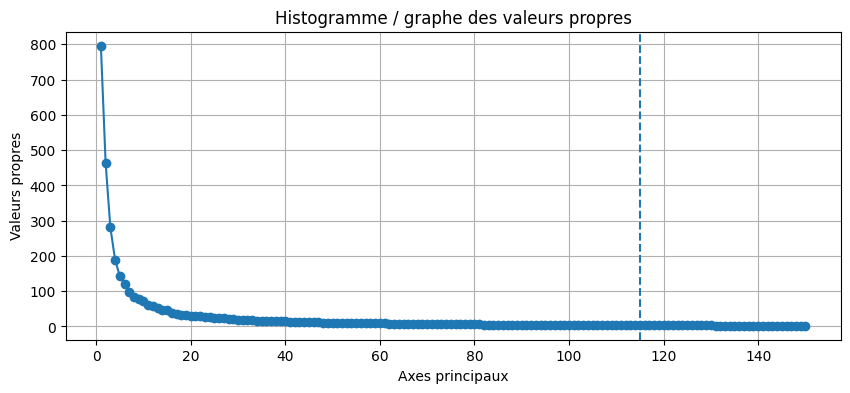

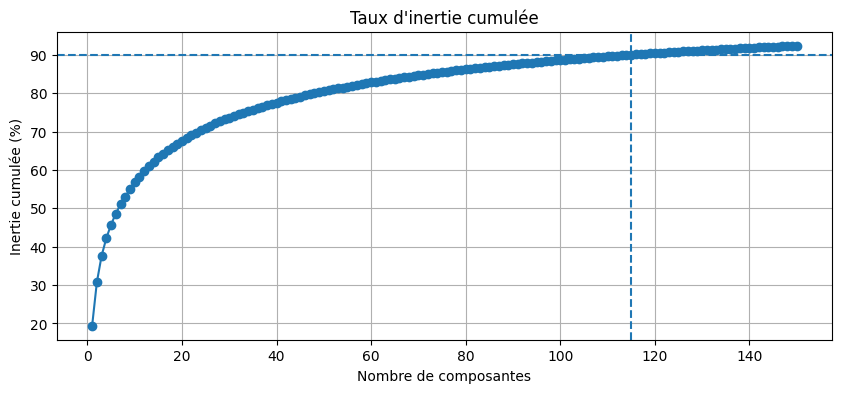

In [41]:
# ============================================================
# 12) GRAPHIQUES : VALEURS PROPRES ET INERTIE CUMULÉE
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.axvline(n_selected, linestyle='--')
plt.title('Histogramme / graphe des valeurs propres')
plt.xlabel('Axes principaux')
plt.ylabel('Valeurs propres')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cum_inertia)+1), cum_inertia*100, marker='o')
plt.axhline(VARIANCE_TO_KEEP*100, linestyle='--')
plt.axvline(n_selected, linestyle='--')
plt.title("Taux d'inertie cumulée")
plt.xlabel('Nombre de composantes')
plt.ylabel('Inertie cumulée (%)')
plt.grid(True)
plt.show()


In [42]:
# ============================================================
# 13) PROJECTION DES INDIVIDUS SUR LES AXES RETENUS
# ============================================================

C_tr = C_tr_full[:, :n_selected]
C_val = C_val_full[:, :n_selected]

proj_train_table = pd.DataFrame(C_tr[:, :min(3, n_selected)], columns=[f'C{i+1}' for i in range(min(3, n_selected))])
proj_train_table.insert(0, 'Classe', pd.Series(y_tr).map(CLASS_NAMES).values)
proj_train_table.insert(0, 'Image', [p.name for p in paths_tr])
proj_train_table.head(10)


,Image,Classe,C1,C2,C3
0,9_8.avi_125_fake.jpg,Fake,-10.758715,24.074438,12.276604
1,1_7.avi_175_fake.jpg,Fake,10.064582,59.406971,-5.231623
2,4_6.avi_125_fake.jpg,Fake,16.931225,-28.320925,-13.079768
3,16_8.avi_100_fake.jpg,Fake,-14.170636,15.104830,-6.512302
4,3_3.avi_50_fake.jpg,Fake,35.471081,-6.715652,-29.676367
5,4_8.avi_175_fake.jpg,Fake,-19.209036,-24.544724,-0.208257
6,17_HR_3.avi_75_fake.jpg,Fake,-33.049038,-22.542339,-7.246144
7,13_7.avi_75_fake.jpg,Fake,-7.176201,25.304699,26.991385
8,4_HR_2.avi_200_fake.jpg,Fake,-35.593472,-34.366039,3.051189
9,11_HR_3.avi_50_fake.jpg,Fake,-14.282845,-10.641261,15.187913


## 13 bis) Choix du nombre d’axes pour la classification

In [ ]:


candidate_axes = sorted(set([c for c in AXES_CANDIDATES if 2 <= c <= C_tr_full.shape[1]] + [n_selected]))
axes_results = []

for nb_axes in candidate_axes:
    Ctr_tmp = C_tr_full[:, :nb_axes]
    Cval_tmp = C_val_full[:, :nb_axes]

    clf_tmp = SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced' if USE_CLASS_WEIGHT_BALANCED else None,
        probability=True,
        random_state=RANDOM_STATE
    )
    clf_tmp.fit(Ctr_tmp, y_tr)
    pred_tmp = clf_tmp.predict(Cval_tmp)

    axes_results.append({
        "Nombre d'axes": nb_axes,
        "Inertie cumulée (%)": float(cum_inertia[nb_axes-1] * 100),
        "Accuracy": accuracy_score(y_val, pred_tmp),
        "Balanced accuracy": balanced_accuracy_score(y_val, pred_tmp),
        "F1-score macro": f1_score(y_val, pred_tmp, average='macro'),
        "Real prédits Fake": int(((y_val == 1) & (pred_tmp == 0)).sum()),
        "Fake prédits Real": int(((y_val == 0) & (pred_tmp == 1)).sum()),
    })

axes_results_df = pd.DataFrame(axes_results).sort_values(
    ["Balanced accuracy", "F1-score macro", "Nombre d'axes"],
    ascending=[False, False, True]
)

display(axes_results_df)

n_selected_inertia = n_selected
if USE_BEST_AXES_FOR_CLASSIFICATION:
    n_selected_model = int(axes_results_df.iloc[0]["Nombre d'axes"])
else:
    n_selected_model = n_selected_inertia

# À partir de maintenant, C_tr et C_val utilisent le nombre d'axes choisi pour la classification.
n_selected = n_selected_model
C_tr = C_tr_full[:, :n_selected]
C_val = C_val_full[:, :n_selected]

print(f"Axes retenus par inertie : {n_selected_inertia} axes => {cum_inertia[n_selected_inertia-1]*100:.2f}%")
print(f"Axes utilisés pour le modèle final : {n_selected} axes => {cum_inertia[n_selected-1]*100:.2f}%")
print("Remarque : si les deux nombres sont différents, on le mentionne dans le rapport comme optimisation validée expérimentalement.")

,Nombre d'axes,Inertie cumulée (%),Accuracy,Balanced accuracy,F1-score macro,Real prédits Fake,Fake prédits Real
7,150,92.357857,0.978261,0.962152,0.970026,7,2
5,115,90.010506,0.975845,0.960554,0.966811,7,3
6,120,90.415802,0.975845,0.960554,0.966811,7,3
1,40,77.562157,0.973430,0.958957,0.963618,7,4
3,80,86.204079,0.975845,0.957201,0.966578,8,2
4,100,88.622978,0.975845,0.957201,0.966578,8,2
0,20,67.545959,0.973430,0.955604,0.963365,8,3
2,59,82.593040,0.973430,0.955604,0.963365,8,3


Axes retenus par inertie : 115 axes => 90.01%
Axes utilisés pour le modèle final : 150 axes => 92.36%
Remarque : si les deux nombres sont différents, on le mentionne dans le rapport comme optimisation validée expérimentalement.


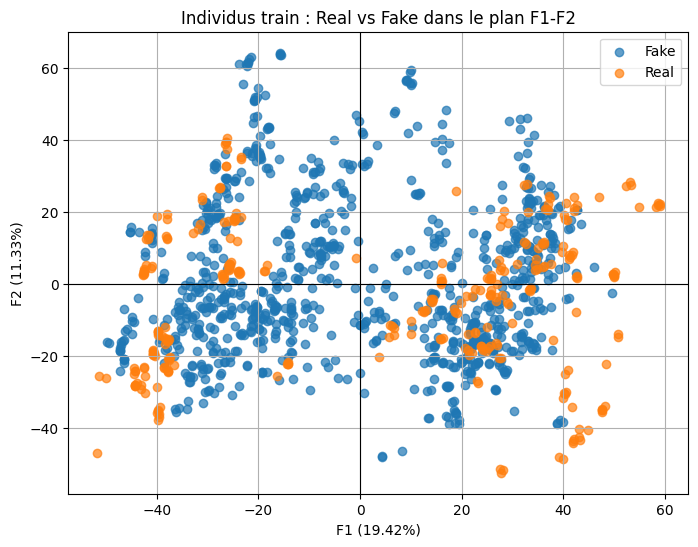

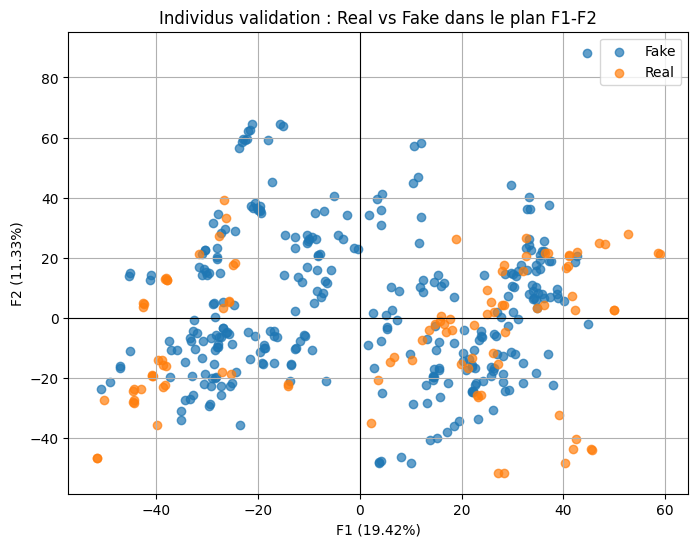

In [ ]:


def plot_individuals(C, y, title='Projection des individus F1-F2'):
    plt.figure(figsize=(8, 6))
    for lab in np.unique(y):
        idx = (y == lab)
        plt.scatter(C[idx, 0], C[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.7)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f'F1 ({inertia_ratio[0]*100:.2f}%)')
    plt.ylabel(f'F2 ({inertia_ratio[1]*100:.2f}%)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_individuals(C_tr_full, y_tr, 'Individus train : Real vs Fake dans le plan F1-F2')
plot_individuals(C_val_full, y_val, 'Individus validation : Real vs Fake dans le plan F1-F2')


In [45]:
# ============================================================
# 15) QUALITÉ DE REPRÉSENTATION DES INDIVIDUS : cos²
# ============================================================
# Formule : cos²(i, axe j) = c_ij² / ||z_i||²
# Plus la valeur est proche de 1, meilleure est la représentation sur l'axe.

def individual_cos2(Z_data, C_data, paths, y_data, n_axes=3):
    n_axes = min(n_axes, C_data.shape[1])
    dist2 = np.sum(Z_data**2, axis=1)
    dist2[dist2 == 0] = 1e-12
    cos2 = (C_data[:, :n_axes] ** 2) / dist2[:, None]
    df = pd.DataFrame(cos2, columns=[f'Qualité axe F{i+1}' for i in range(n_axes)])
    df.insert(0, 'Classe', pd.Series(y_data).map(CLASS_NAMES).values)
    df.insert(0, 'Image', [p.name for p in paths])
    return df

cos2_ind_train = individual_cos2(Z_tr, C_tr_full, paths_tr, y_tr, n_axes=3)
cos2_ind_train.head(15)


,Image,Classe,Qualité axe F1,Qualité axe F2,Qualité axe F3
0,9_8.avi_125_fake.jpg,Fake,0.043070,0.215657,0.056080
1,1_7.avi_175_fake.jpg,Fake,0.016828,0.586308,0.004547
2,4_6.avi_125_fake.jpg,Fake,0.090334,0.252749,0.053911
3,16_8.avi_100_fake.jpg,Fake,0.096271,0.109382,0.020332
4,3_3.avi_50_fake.jpg,Fake,0.234728,0.008414,0.164300
5,4_8.avi_175_fake.jpg,Fake,0.121879,0.198991,0.000014
6,17_HR_3.avi_75_fake.jpg,Fake,0.272384,0.126725,0.013094
7,13_7.avi_75_fake.jpg,Fake,0.011895,0.147901,0.168275
8,4_HR_2.avi_200_fake.jpg,Fake,0.283398,0.264189,0.002083
9,11_HR_3.avi_50_fake.jpg,Fake,0.066834,0.037099,0.075573


In [46]:
# ============================================================
# 16) CONTRIBUTION DES INDIVIDUS À L'INERTIE DES AXES
# ============================================================
# Formule pratique : contribution_ij = 100 * c_ij² / somme_i(c_ij²)
# Pour chaque axe, la somme des contributions = 100%.

def individual_contributions(C_data, paths, y_data, n_axes=3):
    n_axes = min(n_axes, C_data.shape[1])
    scores2 = C_data[:, :n_axes] ** 2
    denom = scores2.sum(axis=0)
    denom[denom == 0] = 1e-12
    contrib = 100 * scores2 / denom
    df = pd.DataFrame(contrib, columns=[f'Contribution F{i+1} (%)' for i in range(n_axes)])
    df.insert(0, 'Classe', pd.Series(y_data).map(CLASS_NAMES).values)
    df.insert(0, 'Image', [p.name for p in paths])
    return df

contrib_ind_train = individual_contributions(C_tr_full, paths_tr, y_tr, n_axes=3)
contrib_ind_train.head(15)


,Image,Classe,Contribution F1 (%),Contribution F2 (%),Contribution F3 (%)
0,9_8.avi_125_fake.jpg,Fake,0.011726,0.100654,0.043231
1,1_7.avi_175_fake.jpg,Fake,0.010262,0.612903,0.007851
2,4_6.avi_125_fake.jpg,Fake,0.029041,0.139294,0.049073
3,16_8.avi_100_fake.jpg,Fake,0.020343,0.039623,0.012165
4,3_3.avi_50_fake.jpg,Fake,0.127463,0.007832,0.252615
5,4_8.avi_175_fake.jpg,Fake,0.037381,0.104624,0.000012
6,17_HR_3.avi_75_fake.jpg,Fake,0.110651,0.088250,0.015061
7,13_7.avi_75_fake.jpg,Fake,0.005217,0.111204,0.208972
8,4_HR_2.avi_200_fake.jpg,Fake,0.128344,0.205105,0.002670
9,11_HR_3.avi_50_fake.jpg,Fake,0.020666,0.019665,0.066166


In [47]:
# ============================================================
# 17) INDIVIDUS MAL REPRÉSENTÉS SUR LE PLAN F1-F2
# ============================================================
# Qualité du plan = cos²(F1) + cos²(F2).
# Seuil proposé : < 0.30 => mal représenté.

cos2_plane = cos2_ind_train['Qualité axe F1'] + cos2_ind_train['Qualité axe F2']
mal_represented = cos2_ind_train.copy()
mal_represented['Qualité plan F1-F2'] = cos2_plane
mal_represented['Signe F1'] = np.where(C_tr_full[:, 0] >= 0, '+', '-')
mal_represented['Signe F2'] = np.where(C_tr_full[:, 1] >= 0, '+', '-')
mal_represented = mal_represented.sort_values('Qualité plan F1-F2')
mal_represented.head(20)


,Image,Classe,Qualité axe F1,Qualité axe F2,Qualité axe F3,Qualité plan F1-F2,Signe F1,Signe F2
1186,7_HR_2.avi_150_fake.jpg,Fake,0.000204,0.000289,0.120389,0.000493,-,-
912,18_5.avi_50_fake.jpg,Fake,0.001867,0.000444,0.079024,0.002311,+,-
12,7_HR_2.avi_125_fake.jpg,Fake,0.001417,0.004315,0.106657,0.005732,+,+
463,12_8.avi_175_fake.jpg,Fake,0.009651,0.000077,0.023518,0.009729,-,+
784,11_5.avi_25_fake.jpg,Fake,0.010245,0.000463,0.024841,0.010708,+,-
757,18_5.avi_75_fake.jpg,Fake,0.010975,0.000004,0.107784,0.010979,+,-
858,5_HR_1.avi_125_real.jpg,Real,0.000192,0.012218,0.245695,0.012409,-,+
839,18_6.avi_25_fake.jpg,Fake,0.001907,0.017141,0.030042,0.019048,+,-
672,12_8.avi_150_fake.jpg,Fake,0.020275,0.001665,0.047687,0.021940,-,+
823,20_8.avi_50_fake.jpg,Fake,0.022039,0.000706,0.208845,0.022746,-,+


In [ ]:
# 18) ANALYSE DES VARIABLES / PIXELS : COORDONNÉES SUR LES AXES


n_axes_var = min(3, pca_full.components_.shape[0])
var_coords = pca_full.components_[:n_axes_var].T * np.sqrt(pca_full.explained_variance_[:n_axes_var])

def pixel_labels(n_features, img_size=IMG_SIZE, modality=MODALITY):
    h, w = img_size[1], img_size[0]
    base_n = h * w
    labels = []
    if modality in ['color', 'depth']:
        prefix = 'px' if modality == 'color' else 'dpx'
        for idx in range(n_features):
            r, c = divmod(idx, w)
            labels.append(f'{prefix}({r},{c})')
    else:
        for idx in range(n_features):
            part = 'color' if idx < base_n else 'depth'
            local = idx if idx < base_n else idx - base_n
            r, c = divmod(local, w)
            labels.append(f'{part}({r},{c})')
    return labels

var_labels = pixel_labels(X.shape[1], IMG_SIZE, MODALITY)
var_table = pd.DataFrame(var_coords, columns=[f'Coord F{i+1}' for i in range(n_axes_var)])
var_table.insert(0, 'Variable', var_labels)
var_table.head(10)


,Variable,Coord F1,Coord F2,Coord F3
0,"px(0,0)",0.836790,-0.122029,-0.008041
1,"px(0,1)",0.850174,-0.110731,0.023903
2,"px(0,2)",0.857900,-0.106241,0.029777
3,"px(0,3)",0.857845,-0.118997,0.037776
4,"px(0,4)",0.855185,-0.123546,0.036612
5,"px(0,5)",0.845214,-0.110432,0.035735
6,"px(0,6)",0.845638,-0.103179,0.035249
7,"px(0,7)",0.833734,-0.086407,0.039556
8,"px(0,8)",0.824019,-0.085311,0.039850
9,"px(0,9)",0.709698,-0.089791,0.020543


In [ ]:
# 19) QUALITÉ ET CONTRIBUTION DES VARIABLES

# # Qualité variable sur axe = corr²rr²
# Contribution variable à l'axe = 100 * corr² / lambda_axe

var_cos2 = var_coords ** 2
var_contrib = 100 * var_cos2 / pca_full.explained_variance_[:n_axes_var]

var_quality_table = pd.DataFrame(var_cos2, columns=[f'Qualité F{i+1}' for i in range(n_axes_var)])
var_quality_table.insert(0, 'Variable', var_labels)

var_contrib_table = pd.DataFrame(var_contrib, columns=[f'Contribution F{i+1} (%)' for i in range(n_axes_var)])
var_contrib_table.insert(0, 'Variable', var_labels)

# Top pixels qui expliquent le plus F1-F2
top_score = var_contrib[:, 0] + var_contrib[:, 1]
top_idx = np.argsort(top_score)[::-1][:20]

print('Top 20 variables/pixels les plus importantes pour F1-F2 :')
display(var_contrib_table.iloc[top_idx])


Top 20 variables/pixels les plus importantes pour F1-F2 :


,Variable,Contribution F1 (%),Contribution F2 (%),Contribution F3 (%)
2670,"px(41,46)",0.000014,0.130598,0.002419
2669,"px(41,45)",0.000088,0.130124,0.003166
2606,"px(40,46)",0.000036,0.129122,0.004915
2733,"px(42,45)",0.000658,0.126090,0.000101
2671,"px(41,47)",0.000004,0.126716,0.001877
2605,"px(40,45)",0.000037,0.126329,0.006968
2734,"px(42,46)",0.000304,0.124559,0.000215
2607,"px(40,47)",0.000007,0.124421,0.004113
2775,"px(43,23)",0.001539,0.122239,0.000007
2711,"px(42,23)",0.000895,0.122083,0.000477


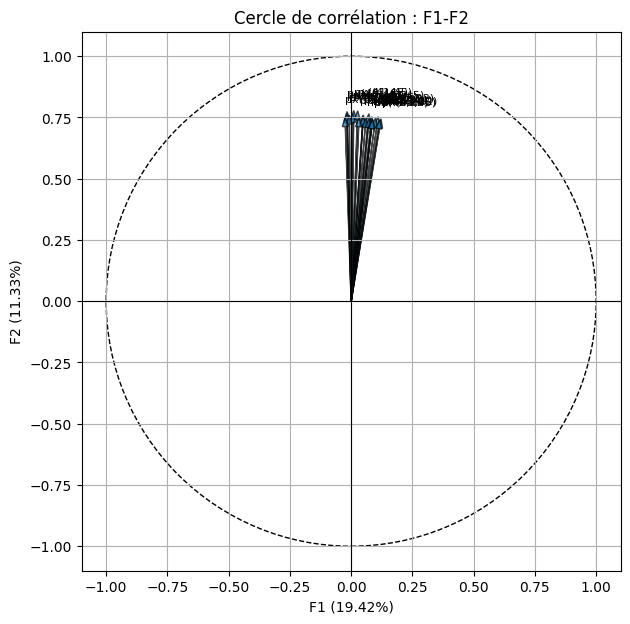

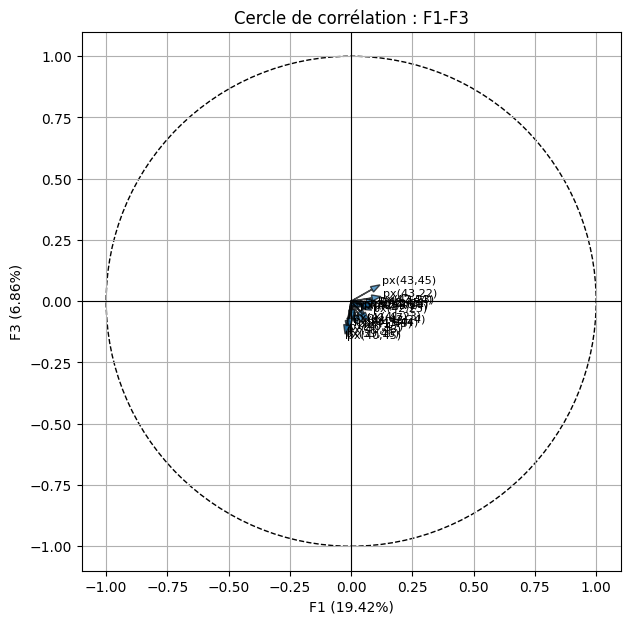

In [ ]:

# 20) CERCLE DE CORRÉLATION DES VARIABLES IMPORTANTES

# Comme les variables sont les pixels, on affiche seulement les pixels les plus contributifs.

def plot_correlation_circle(var_coords, top_idx, ax1=0, ax2=1, title='Cercle de corrélation'):
    fig, ax = plt.subplots(figsize=(7, 7))
    circle = plt.Circle((0, 0), 1, fill=False, linestyle='--')
    ax.add_artist(circle)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    for idx in top_idx:
        x = var_coords[idx, ax1]
        y = var_coords[idx, ax2]
        ax.arrow(0, 0, x, y, head_width=0.025, length_includes_head=True, alpha=0.7)
        ax.text(x*1.08, y*1.08, var_labels[idx], fontsize=8)

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel(f'F{ax1+1} ({inertia_ratio[ax1]*100:.2f}%)')
    ax.set_ylabel(f'F{ax2+1} ({inertia_ratio[ax2]*100:.2f}%)')
    ax.set_title(title)
    ax.grid(True)
    plt.show()

plot_correlation_circle(var_coords, top_idx, 0, 1, 'Cercle de corrélation : F1-F2')
if n_axes_var >= 3:
    plot_correlation_circle(var_coords, top_idx, 0, 2, 'Cercle de corrélation : F1-F3')


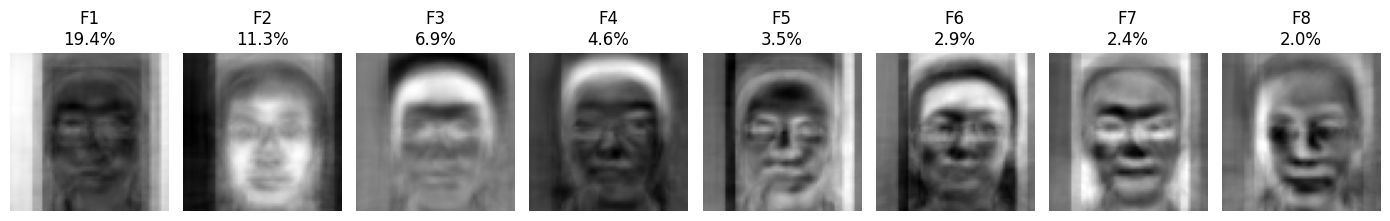

In [ ]:
# 21) EIGENFACES / COMPOSANTES PRINCIPALES SOUS FORME D'IMAGES

# Cela aide à interpréter visuellement ce que les axes ACP capturent.

def show_eigenfaces(pca, img_size=IMG_SIZE, n=8, modality=MODALITY):
    n = min(n, pca.components_.shape[0])
    w, h = img_size
    plt.figure(figsize=(14, 3))
    for i in range(n):
        comp = pca.components_[i]
        if modality == 'color_depth':
            comp = comp[:w*h]  # affiche seulement partie color
        img = comp.reshape(h, w)
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'F{i+1}\n{inertia_ratio[i]*100:.1f}%')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_eigenfaces(pca_full, IMG_SIZE, n=8, modality=MODALITY)


In [ ]:


balanced_weight = 'balanced' if USE_CLASS_WEIGHT_BALANCED else None

models = {
    'Logistic Regression équilibrée': LogisticRegression(max_iter=3000, class_weight=balanced_weight, random_state=RANDOM_STATE),
    'SVM Linear équilibré': SVC(kernel='linear', C=1, class_weight=balanced_weight, probability=True, random_state=RANDOM_STATE),
    'SVM RBF équilibré': SVC(kernel='rbf', C=10, gamma='scale', class_weight=balanced_weight, probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest équilibré': RandomForestClassifier(n_estimators=250, class_weight=balanced_weight, random_state=RANDOM_STATE),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(C_tr, y_tr)
    y_pred = model.predict(C_val)
    results.append({
        'Modèle': name,
        'Accuracy validation': accuracy_score(y_val, y_pred),
        'Balanced accuracy': balanced_accuracy_score(y_val, y_pred),
        'F1-score macro': f1_score(y_val, y_pred, average='macro'),
        'Real prédits Fake': int(((y_val == 1) & (y_pred == 0)).sum()),
        'Fake prédits Real': int(((y_val == 0) & (y_pred == 1)).sum()),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(['Balanced accuracy', 'F1-score macro'], ascending=False)
display(results_df)

,Modèle,Accuracy validation,Balanced accuracy,F1-score macro,Real prédits Fake,Fake prédits Real
2,SVM RBF équilibré,0.978261,0.962152,0.970026,7,2
0,Logistic Regression équilibrée,0.910628,0.907364,0.885147,10,27
1,SVM Linear équilibré,0.905797,0.900816,0.878939,11,28
4,Random Forest équilibré,0.929952,0.859789,0.894938,28,1
3,KNN,0.913043,0.855313,0.875188,26,10


Meilleur modèle : SVM RBF équilibré
Nombre d'axes ACP utilisés : 150
Accuracy validation : 0.9782608695652174
Balanced accuracy : 0.9621516464745516
F1-score macro : 0.9700258231636191

Classification report :
              precision    recall  f1-score   support

        Fake       0.98      0.99      0.99       313
        Real       0.98      0.93      0.95       101

    accuracy                           0.98       414
   macro avg       0.98      0.96      0.97       414
weighted avg       0.98      0.98      0.98       414



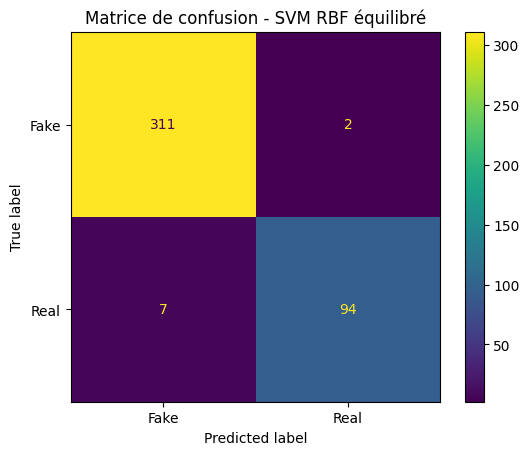

Erreurs Real classées Fake : 7
Erreurs Fake classées Real : 2


In [ ]:
# 23) MEILLEUR MODÈLE 


best_model_name = results_df.iloc[0]['Modèle']
best_model = trained_models[best_model_name]
y_val_pred = best_model.predict(C_val)

print('Meilleur modèle :', best_model_name)
print('Nombre d\'axes ACP utilisés :', n_selected)
print('Accuracy validation :', accuracy_score(y_val, y_val_pred))
print('Balanced accuracy :', balanced_accuracy_score(y_val, y_val_pred))
print('F1-score macro :', f1_score(y_val, y_val_pred, average='macro'))
print('\nClassification report :')
print(classification_report(y_val, y_val_pred, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))

cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]])
disp.plot(values_format='d')
plt.title(f'Matrice de confusion - {best_model_name}')
plt.show()

# Analyse ciblée du biais Real -> Fake
nb_real_to_fake = int(((y_val == 1) & (y_val_pred == 0)).sum())
nb_fake_to_real = int(((y_val == 0) & (y_val_pred == 1)).sum())
print('Erreurs Real classées Fake :', nb_real_to_fake)
print('Erreurs Fake classées Real :', nb_fake_to_real)

## 23 bis) Calibration du seuil Real/Fake et analyse des erreurs

Cette section répond au problème observé pendant les tests externes : certaines images réellement humaines sont prédites **Fake**.  
La correction reste dans le cadre ACP : on ne change pas le pipeline **X → Z → ACP → SVM**, mais on calibre le seuil de décision à partir de la validation.

Au lieu d'utiliser automatiquement le seuil 0,50 pour la classe Real, on teste plusieurs seuils et on retient celui qui donne le meilleur compromis entre :

- balanced accuracy ;
- rappel de la classe Real ;
- rappel de la classe Fake.

Ainsi, si le modèle donne par exemple Real = 36 % et Fake = 64 %, on peut éviter de conclure trop vite Fake lorsque la validation montre que le seuil Real optimal est plus bas.

In [54]:
from sklearn.metrics import recall_score

# ============================================================
# 23 bis-A) CALIBRATION DU SEUIL REAL / FAKE APRÈS ACP
# ============================================================
# Objectif : réduire les erreurs Real -> Fake tout en gardant une bonne détection Fake.
# On utilise les probabilités du meilleur modèle sur la validation.

REAL_LABEL = 1
FAKE_LABEL = 0

if not hasattr(best_model, 'predict_proba'):
    print("Le meilleur modèle ne fournit pas predict_proba. Seuil par défaut utilisé.")
    BEST_REAL_THRESHOLD = BEST_REAL_THRESHOLD_FALLBACK
    y_val_pred_calibrated = y_val_pred.copy()
    threshold_results_df = pd.DataFrame()
else:
    val_proba = best_model.predict_proba(C_val)
    model_classes = list(best_model.classes_)
    print("Ordre des classes dans le modèle :", model_classes)

    real_idx = model_classes.index(REAL_LABEL)
    fake_idx = model_classes.index(FAKE_LABEL)
    proba_real_val = val_proba[:, real_idx]
    proba_fake_val = val_proba[:, fake_idx]

    thresholds = np.arange(REAL_THRESHOLD_MIN, REAL_THRESHOLD_MAX + 1e-9, REAL_THRESHOLD_STEP)
    rows = []

    for t in thresholds:
        # Si proba Real dépasse le seuil calibré -> Real, sinon Fake.
        pred_t = np.where(proba_real_val >= t, REAL_LABEL, FAKE_LABEL)
        bal_acc = balanced_accuracy_score(y_val, pred_t)
        real_recall = recall_score(y_val, pred_t, pos_label=REAL_LABEL, zero_division=0)
        fake_recall = recall_score(y_val, pred_t, pos_label=FAKE_LABEL, zero_division=0)
        real_to_fake = int(((y_val == REAL_LABEL) & (pred_t == FAKE_LABEL)).sum())
        fake_to_real = int(((y_val == FAKE_LABEL) & (pred_t == REAL_LABEL)).sum())

        # Score de choix : équilibré, avec légère priorité au rappel Real.
        score = bal_acc + REAL_RECALL_PRIORITY * real_recall
        rows.append({
            "Seuil Real": float(t),
            "Balanced accuracy": bal_acc,
            "Recall Real": real_recall,
            "Recall Fake": fake_recall,
            "Real prédits Fake": real_to_fake,
            "Fake prédits Real": fake_to_real,
            "Score choix": score,
        })

    threshold_results_df = pd.DataFrame(rows).sort_values(
        ["Score choix", "Balanced accuracy", "Recall Fake"],
        ascending=[False, False, False]
    )
    display(threshold_results_df.head(12))

    if CALIBRATE_REAL_THRESHOLD and len(threshold_results_df) > 0:
        BEST_REAL_THRESHOLD = float(threshold_results_df.iloc[0]["Seuil Real"])
    else:
        BEST_REAL_THRESHOLD = 0.50

    y_val_pred_calibrated = np.where(proba_real_val >= BEST_REAL_THRESHOLD, REAL_LABEL, FAKE_LABEL)

    print("Seuil Real retenu =", BEST_REAL_THRESHOLD)
    print("Ancien seuil implicite = 0.50")
    print("Balanced accuracy calibrée :", balanced_accuracy_score(y_val, y_val_pred_calibrated))
    print("Rappel Real calibré :", recall_score(y_val, y_val_pred_calibrated, pos_label=REAL_LABEL, zero_division=0))
    print("Rappel Fake calibré :", recall_score(y_val, y_val_pred_calibrated, pos_label=FAKE_LABEL, zero_division=0))

    # Tableau comparatif avant / après calibration
    comparison_threshold_df = pd.DataFrame([
        {
            "Décision": "Standard model.predict()",
            "Balanced accuracy": balanced_accuracy_score(y_val, y_val_pred),
            "Recall Real": recall_score(y_val, y_val_pred, pos_label=REAL_LABEL, zero_division=0),
            "Recall Fake": recall_score(y_val, y_val_pred, pos_label=FAKE_LABEL, zero_division=0),
            "Real prédits Fake": int(((y_val == REAL_LABEL) & (y_val_pred == FAKE_LABEL)).sum()),
            "Fake prédits Real": int(((y_val == FAKE_LABEL) & (y_val_pred == REAL_LABEL)).sum()),
        },
        {
            "Décision": f"Seuil Real calibré = {BEST_REAL_THRESHOLD:.2f}",
            "Balanced accuracy": balanced_accuracy_score(y_val, y_val_pred_calibrated),
            "Recall Real": recall_score(y_val, y_val_pred_calibrated, pos_label=REAL_LABEL, zero_division=0),
            "Recall Fake": recall_score(y_val, y_val_pred_calibrated, pos_label=FAKE_LABEL, zero_division=0),
            "Real prédits Fake": int(((y_val == REAL_LABEL) & (y_val_pred_calibrated == FAKE_LABEL)).sum()),
            "Fake prédits Real": int(((y_val == FAKE_LABEL) & (y_val_pred_calibrated == REAL_LABEL)).sum()),
        }
    ])
    display(comparison_threshold_df)

    try:
        threshold_results_df.to_csv(OUTPUT_DIR / "17_calibration_seuil_real.csv", index=False)
        comparison_threshold_df.to_csv(OUTPUT_DIR / "18_comparaison_avant_apres_calibration.csv", index=False)
    except Exception:
        pass

Ordre des classes dans le modèle : [np.int64(0), np.int64(1)]


,Seuil Real,Balanced accuracy,Recall Real,Recall Fake,Real prédits Fake,Fake prédits Real,Score choix
0,0.20,0.968858,0.950495,0.987220,5,4,1.111432
1,0.21,0.965505,0.940594,0.990415,6,3,1.106594
2,0.22,0.965505,0.940594,0.990415,6,3,1.106594
3,0.23,0.965505,0.940594,0.990415,6,3,1.106594
4,0.24,0.965505,0.940594,0.990415,6,3,1.106594
5,0.25,0.965505,0.940594,0.990415,6,3,1.106594
6,0.26,0.965505,0.940594,0.990415,6,3,1.106594
7,0.27,0.965505,0.940594,0.990415,6,3,1.106594
8,0.28,0.965505,0.940594,0.990415,6,3,1.106594
9,0.29,0.965505,0.940594,0.990415,6,3,1.106594


Seuil Real retenu = 0.2
Ancien seuil implicite = 0.50
Balanced accuracy calibrée : 0.9688577483946477
Rappel Real calibré : 0.9504950495049505
Rappel Fake calibré : 0.987220447284345


,Décision,Balanced accuracy,Recall Real,Recall Fake,Real prédits Fake,Fake prédits Real
0,Standard model.predict(),0.962152,0.930693,0.99361,7,2
1,Seuil Real calibré = 0.20,0.968858,0.950495,0.98722,5,4


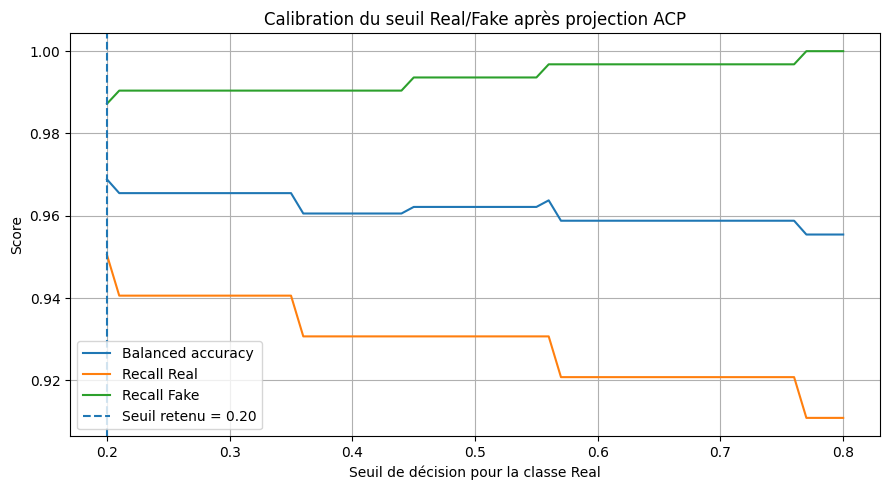

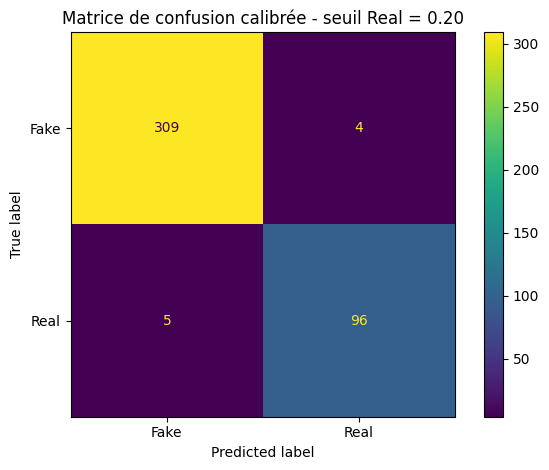

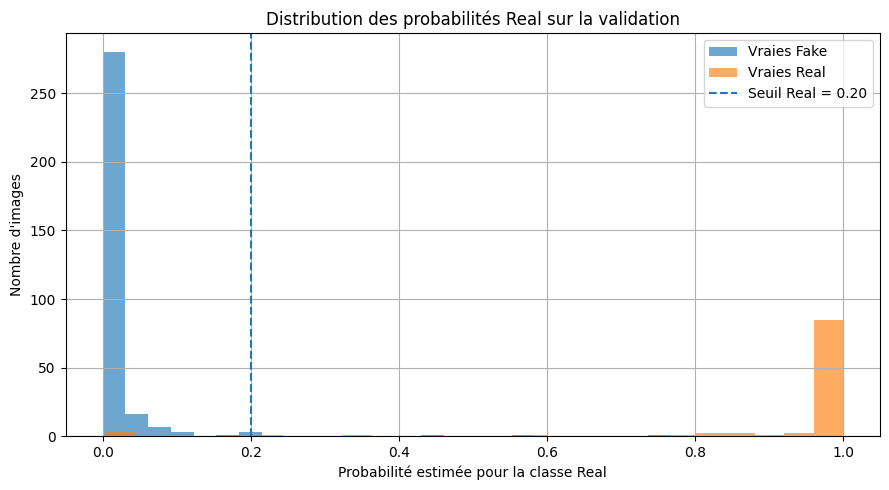

In [ ]:
# 23 bis-B) GRAPHES DE CALIBRATION ET MATRICE DE CONFUSION CALIBRÉE

# Ces graphes sont utiles pour le rapport et correspondent à l'analyse demandée :
# interpréter les erreurs et ne pas se limiter à une prédiction brute.

if 'threshold_results_df' in globals() and len(threshold_results_df) > 0:
    df_thr_plot = threshold_results_df.sort_values("Seuil Real")

    plt.figure(figsize=(9, 5))
    plt.plot(df_thr_plot["Seuil Real"], df_thr_plot["Balanced accuracy"], label="Balanced accuracy")
    plt.plot(df_thr_plot["Seuil Real"], df_thr_plot["Recall Real"], label="Recall Real")
    plt.plot(df_thr_plot["Seuil Real"], df_thr_plot["Recall Fake"], label="Recall Fake")
    plt.axvline(BEST_REAL_THRESHOLD, linestyle="--", label=f"Seuil retenu = {BEST_REAL_THRESHOLD:.2f}")
    plt.xlabel("Seuil de décision pour la classe Real")
    plt.ylabel("Score")
    plt.title("Calibration du seuil Real/Fake après projection ACP")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "19_courbe_calibration_seuil_real.png", dpi=200, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

    cm_cal = confusion_matrix(y_val, y_val_pred_calibrated, labels=[FAKE_LABEL, REAL_LABEL])
    ConfusionMatrixDisplay(cm_cal, display_labels=[CLASS_NAMES[FAKE_LABEL], CLASS_NAMES[REAL_LABEL]]).plot(values_format='d')
    plt.title(f"Matrice de confusion calibrée - seuil Real = {BEST_REAL_THRESHOLD:.2f}")
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "20_matrice_confusion_calibree.png", dpi=200, bbox_inches="tight")
    except Exception:
        pass
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.hist(proba_real_val[y_val == FAKE_LABEL], bins=25, alpha=0.65, label="Vraies Fake")
    plt.hist(proba_real_val[y_val == REAL_LABEL], bins=25, alpha=0.65, label="Vraies Real")
    plt.axvline(BEST_REAL_THRESHOLD, linestyle="--", label=f"Seuil Real = {BEST_REAL_THRESHOLD:.2f}")
    plt.xlabel("Probabilité estimée pour la classe Real")
    plt.ylabel("Nombre d'images")
    plt.title("Distribution des probabilités Real sur la validation")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "21_histogramme_probabilites_real.png", dpi=200, bbox_inches="tight")
    except Exception:
        pass
    plt.show()
else:
    print("Calibration non disponible : modèle sans probabilités ou cellule précédente non exécutée.")


Nombre d'erreurs après calibration : 9 / 414


,Image,Vraie classe,Classe prédite calibrée,F1,F2,Proba Real
0,5_2.avi_100_real.jpg,Real,Fake,17.641432,-0.339058,0.005128
1,11_HR_1.avi_200_real.jpg,Real,Fake,-25.275749,-18.927671,0.006438
2,20_HR_2.avi_125_fake.jpg,Fake,Real,-49.018471,-21.487625,0.767391
3,7_4.avi_125_fake.jpg,Fake,Real,44.646465,88.254333,0.554345
4,10_1.avi_75_real.jpg,Real,Fake,2.194318,-35.161964,0.035900
5,13_1.avi_150_real.jpg,Real,Fake,24.980833,9.106751,0.024159
6,11_HR_1.avi_325_real.jpg,Real,Fake,-26.999907,-18.095835,0.067634
7,20_HR_2.avi_75_fake.jpg,Fake,Real,-50.948788,-23.709064,0.201446
8,13_6.avi_150_fake.jpg,Fake,Real,9.869653,-12.023803,0.446578


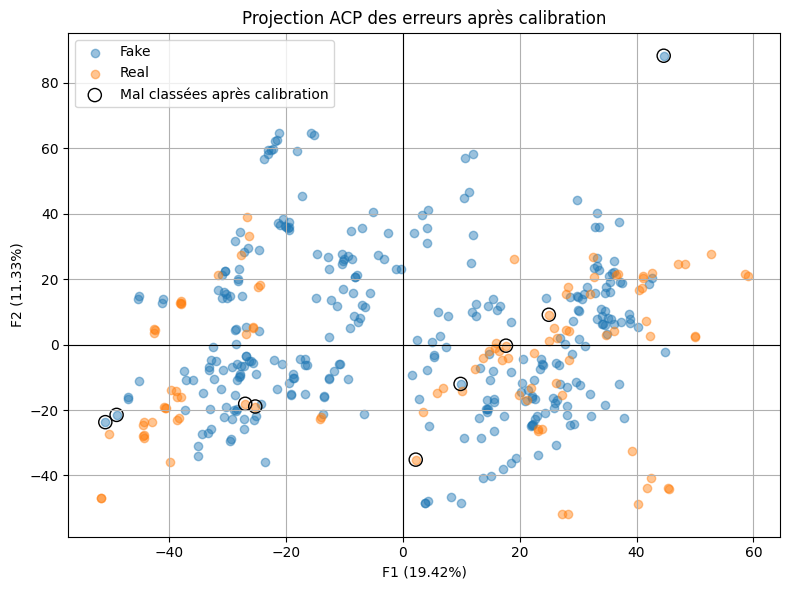

In [ ]:
# 23 bis-C) ERREURS APRÈS CALIBRATION DANS LE PLAN ACP F1-F2

# On visualise les images encore mal classées après calibration.
# C'est directement relié au graphe des individus demandé par le mail.

if 'y_val_pred_calibrated' in globals():
    errors_cal = np.where(y_val != y_val_pred_calibrated)[0]
    errors_cal_df = pd.DataFrame({
        "Image": [paths_val[i].name for i in errors_cal],
        "Vraie classe": pd.Series(y_val[errors_cal]).map(CLASS_NAMES).values,
        "Classe prédite calibrée": pd.Series(y_val_pred_calibrated[errors_cal]).map(CLASS_NAMES).values,
        "F1": C_val_full[errors_cal, 0],
        "F2": C_val_full[errors_cal, 1],
        "Proba Real": proba_real_val[errors_cal] if 'proba_real_val' in globals() else np.nan,
    })
    print("Nombre d'erreurs après calibration :", len(errors_cal), "/", len(y_val))
    display(errors_cal_df.head(25))

    plt.figure(figsize=(8, 6))
    for lab in np.unique(y_val):
        idx = (y_val == lab)
        plt.scatter(C_val_full[idx, 0], C_val_full[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.45)
    if len(errors_cal) > 0:
        plt.scatter(C_val_full[errors_cal, 0], C_val_full[errors_cal, 1],
                    facecolors='none', edgecolors='black', s=90, label='Mal classées après calibration')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f"F1 ({inertia_ratio[0]*100:.2f}%)")
    plt.ylabel(f"F2 ({inertia_ratio[1]*100:.2f}%)")
    plt.title("Projection ACP des erreurs après calibration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / "22_erreurs_calibrees_plan_F1_F2.png", dpi=200, bbox_inches='tight')
        errors_cal_df.to_csv(OUTPUT_DIR / "23_erreurs_calibrees.csv", index=False)
    except Exception:
        pass
    plt.show()
else:
    print("Exécute la calibration du seuil avant cette cellule.")


--- Test officiel : décision standard ---
Accuracy test officiel : 0.840531561461794
Balanced accuracy test officiel : 0.7356364547277219
              precision    recall  f1-score   support

        Fake       0.86      0.94      0.90      1817
        Real       0.75      0.53      0.62       591

    accuracy                           0.84      2408
   macro avg       0.80      0.74      0.76      2408
weighted avg       0.83      0.84      0.83      2408



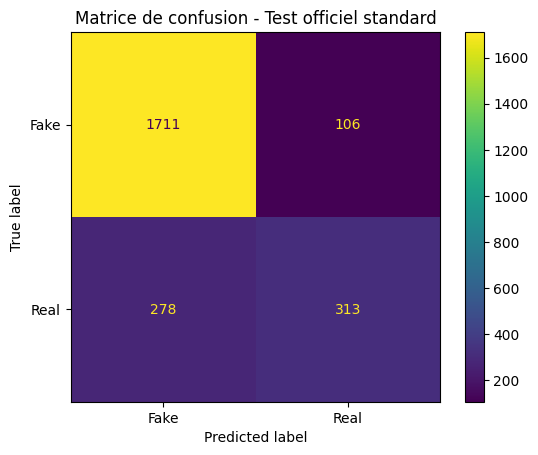


--- Test officiel : décision calibrée ---
Seuil Real utilisé : 0.2
Accuracy test calibrée : 0.8222591362126246
Balanced accuracy test calibrée : 0.7686253255817634
              precision    recall  f1-score   support

        Fake       0.89      0.87      0.88      1817
        Real       0.63      0.66      0.65       591

    accuracy                           0.82      2408
   macro avg       0.76      0.77      0.76      2408
weighted avg       0.83      0.82      0.82      2408



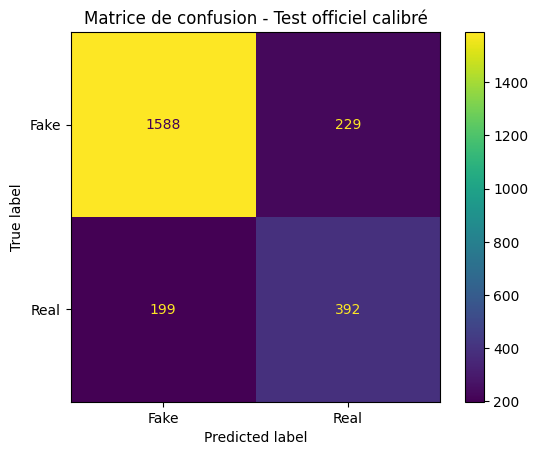

In [ ]:
# 24) ÉVALUATION SUR TEST OFFICIEL SI LABELS DISPONIBLES

# Si le modèle fournit des probabilités, on affiche aussi l'évaluation calibrée.

if X_test_raw.shape[0] > 0:
    Z_test = scaler_model.transform(X_test_raw)
    C_test_full = pca_full.transform(Z_test)
    C_test = C_test_full[:, :n_selected]

    if y_test_raw is not None and len(y_test_raw) == X_test_raw.shape[0] and len(np.unique(y_test_raw)) >= 2:
        y_test_pred = best_model.predict(C_test)
        print('--- Test officiel : décision standard ---')
        print('Accuracy test officiel :', accuracy_score(y_test_raw, y_test_pred))
        print('Balanced accuracy test officiel :', balanced_accuracy_score(y_test_raw, y_test_pred))
        print(classification_report(y_test_raw, y_test_pred, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))
        cm = confusion_matrix(y_test_raw, y_test_pred, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]]).plot(values_format='d')
        plt.title('Matrice de confusion - Test officiel standard')
        plt.show()

        if hasattr(best_model, 'predict_proba') and 'BEST_REAL_THRESHOLD' in globals():
            print('\n--- Test officiel : décision calibrée ---')
            test_proba = best_model.predict_proba(C_test)
            labels_order = list(best_model.classes_)
            real_idx_test = labels_order.index(REAL_LABEL)
            proba_real_test = test_proba[:, real_idx_test]
            y_test_pred_cal = np.where(proba_real_test >= BEST_REAL_THRESHOLD, REAL_LABEL, FAKE_LABEL)

            print('Seuil Real utilisé :', BEST_REAL_THRESHOLD)
            print('Accuracy test calibrée :', accuracy_score(y_test_raw, y_test_pred_cal))
            print('Balanced accuracy test calibrée :', balanced_accuracy_score(y_test_raw, y_test_pred_cal))
            print(classification_report(y_test_raw, y_test_pred_cal, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))
            cm_cal = confusion_matrix(y_test_raw, y_test_pred_cal, labels=[0, 1])
            ConfusionMatrixDisplay(cm_cal, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]]).plot(values_format='d')
            plt.title('Matrice de confusion - Test officiel calibré')
            try:
                plt.savefig(OUTPUT_DIR / '24_matrice_confusion_test_calibree.png', dpi=200, bbox_inches='tight')
            except Exception:
                pass
            plt.show()
    else:
        y_test_pred = best_model.predict(C_test)
        pred_table = pd.DataFrame({
            'Image': [p.name for p in test_paths_kept],
            'Prediction': pd.Series(y_test_pred).map(CLASS_NAMES)
        })
        display(pred_table.head(20))
else:
    print('Aucune image de test trouvée.')


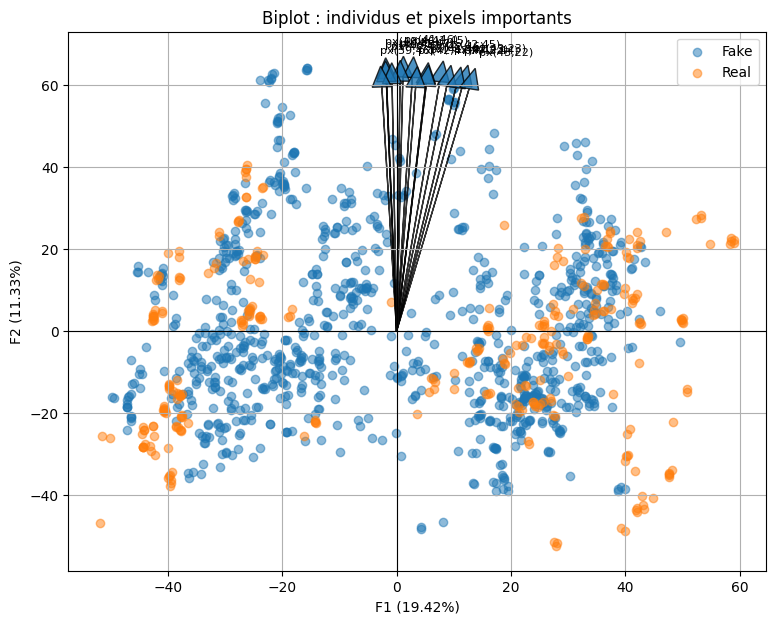

In [ ]:
# 25) BIPLOT : INDIVIDUS + VARIABLES IMPORTANTES
# ============================================================

def plot_biplot(C_data, y_data, var_coords, top_idx, scale=4.0, title='Biplot ACP F1-F2'):
    plt.figure(figsize=(9, 7))
    for lab in np.unique(y_data):
        idx = (y_data == lab)
        plt.scatter(C_data[idx, 0], C_data[idx, 1], alpha=0.5, label=CLASS_NAMES[int(lab)])

    # Variables : on les met à une échelle visible
    sx = np.std(C_data[:, 0]) * scale
    sy = np.std(C_data[:, 1]) * scale
    for idx in top_idx[:15]:
        x = var_coords[idx, 0] * sx
        y = var_coords[idx, 1] * sy
        plt.arrow(0, 0, x, y, head_width=0.03*sx, length_includes_head=True, alpha=0.8)
        plt.text(x*1.05, y*1.05, var_labels[idx], fontsize=8)

    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f'F1 ({inertia_ratio[0]*100:.2f}%)')
    plt.ylabel(f'F2 ({inertia_ratio[1]*100:.2f}%)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_biplot(C_tr_full, y_tr, var_coords, top_idx, title='Biplot : individus et pixels importants')


Nombre d'erreurs validation : 9 / 414


,Image,Vraie classe,Classe prédite,F1,F2
0,5_2.avi_100_real.jpg,Real,Fake,17.641432,-0.339058
1,19_HR_1.avi_175_real.jpg,Real,Fake,-38.056087,-16.005112
2,20_2.avi_125_real.jpg,Real,Fake,19.899033,-15.466998
3,11_HR_1.avi_200_real.jpg,Real,Fake,-25.275749,-18.927671
4,20_HR_2.avi_125_fake.jpg,Fake,Real,-49.018471,-21.487625
5,7_4.avi_125_fake.jpg,Fake,Real,44.646465,88.254333
6,10_1.avi_75_real.jpg,Real,Fake,2.194318,-35.161964
7,13_1.avi_150_real.jpg,Real,Fake,24.980833,9.106751
8,11_HR_1.avi_325_real.jpg,Real,Fake,-26.999907,-18.095835


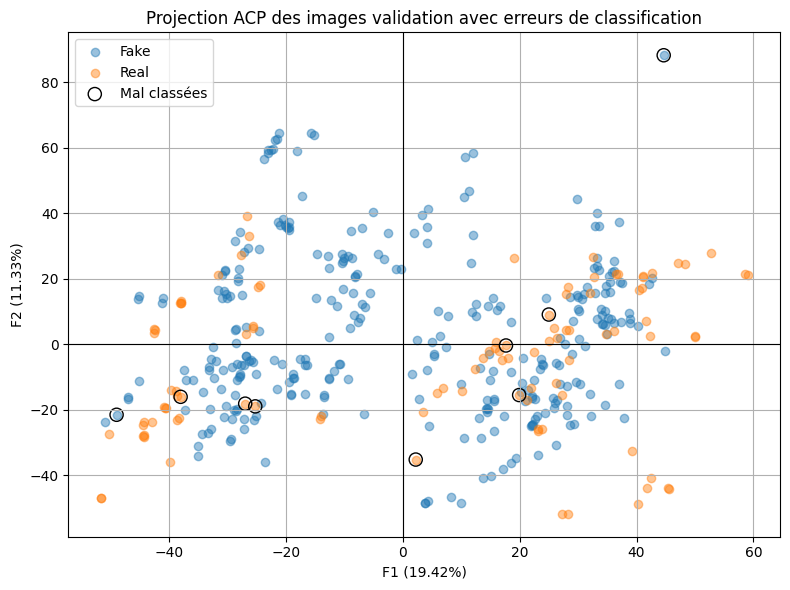

In [60]:
# ============================================================
# 25 bis-0) ERREURS DE CLASSIFICATION DANS LE PLAN ACP F1-F2
# ============================================================

if 'y_val_pred' in globals():
    errors_val = np.where(y_val != y_val_pred)[0]
    errors_val_df = pd.DataFrame({
        'Image': [paths_val[i].name for i in errors_val],
        'Vraie classe': pd.Series(y_val[errors_val]).map(CLASS_NAMES).values,
        'Classe prédite': pd.Series(y_val_pred[errors_val]).map(CLASS_NAMES).values,
        'F1': C_val_full[errors_val, 0],
        'F2': C_val_full[errors_val, 1],
    })
    print('Nombre d\'erreurs validation :', len(errors_val), '/', len(y_val))
    display(errors_val_df.head(20))

    plt.figure(figsize=(8, 6))
    for lab in np.unique(y_val):
        idx = (y_val == lab)
        plt.scatter(C_val_full[idx, 0], C_val_full[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.45)
    if len(errors_val) > 0:
        plt.scatter(C_val_full[errors_val, 0], C_val_full[errors_val, 1],
                    facecolors='none', edgecolors='black', s=90, label='Mal classées')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel(f'F1 ({inertia_ratio[0]*100:.2f}%)')
    plt.ylabel(f'F2 ({inertia_ratio[1]*100:.2f}%)')
    plt.title('Projection ACP des images validation avec erreurs de classification')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    try:
        plt.savefig(OUTPUT_DIR / '00_erreurs_validation_plan_F1_F2.png', dpi=200, bbox_inches='tight')
        errors_val_df.to_csv(OUTPUT_DIR / '00_erreurs_validation.csv', index=False)
    except Exception:
        pass
    plt.show()
else:
    print('Exécute d\'abord la cellule du meilleur modèle pour obtenir y_val_pred.')

In [61]:
# ============================================================
# 25 bis-B) VÉRIFICATION D'UN AXE PROPRE : R.u = lambda.u
# ============================================================
# Dans le cours/TP, les axes principaux sont les vecteurs propres de R.
# Ici sklearn PCA utilise une SVD, mais c'est équivalent pour l'ACP normée.
# On vérifie numériquement la relation pour les 3 premiers axes.

m_train = Z_tr.shape[0]
n_check = min(3, pca_full.components_.shape[0])

verification_rows = []
for k in range(n_check):
    u = pca_full.components_[k]  # vecteur propre / axe factoriel
    # sklearn explained_variance_ utilise 1/(m-1)
    Ru = (Z_tr.T @ (Z_tr @ u)) / (m_train - 1)
    lambda_u = pca_full.explained_variance_[k] * u
    erreur = np.linalg.norm(Ru - lambda_u)
    rel_erreur = erreur / (np.linalg.norm(lambda_u) + 1e-12)
    verification_rows.append({
        "Axe": f"F{k+1}",
        "lambda": pca_full.explained_variance_[k],
        "||R.u - lambda.u||": erreur,
        "Erreur relative": rel_erreur,
        "Validation": "OK" if rel_erreur < 1e-5 else "Approx."
    })

verif_df = pd.DataFrame(verification_rows)
display(verif_df)
verif_df.to_csv(OUTPUT_DIR / "07_verification_vecteurs_propres.csv", index=False)


,Axe,lambda,||R.u - lambda.u||,Erreur relative,Validation
0,F1,796.053833,0.000960,1.205435e-06,OK
1,F2,464.367554,0.000404,8.709575e-07,OK
2,F3,281.151245,0.000243,8.633562e-07,OK


In [ ]:

dist2_ind = np.sum(Z_tr**2, axis=1)
dist_ind_table = pd.DataFrame({
    "Image": [p.name for p in paths_tr],
    "Classe": pd.Series(y_tr).map(CLASS_NAMES).values,
    "Distance² au centre": dist2_ind,
    "F1": C_tr_full[:, 0],
    "F2": C_tr_full[:, 1],
})
dist_ind_table = dist_ind_table.sort_values("Distance² au centre", ascending=False)

print("Somme des distances² au centre =", dist2_ind.sum())
print("Moyenne des distances² au centre =", dist2_ind.mean())
display(dist_ind_table.head(15))

dist_ind_table.to_csv(OUTPUT_DIR / "08_distances_individus_centre.csv", index=False)


Somme des distances² au centre = 5083136.0
Moyenne des distances² au centre = 4096.0


,Image,Classe,Distance² au centre,F1,F2
60,3_1.avi_125_real.jpg,Real,7929.875488,41.723236,-34.122456
157,8_HR_4.avi_75_fake.jpg,Fake,7728.731934,-15.734749,64.339302
1077,8_HR_4.avi_125_fake.jpg,Fake,7723.796875,-15.638122,63.640602
252,7_HR_4.avi_50_fake.jpg,Fake,7680.756836,-21.427797,63.074543
863,8_HR_4.avi_100_fake.jpg,Fake,7674.463379,-15.836577,63.743282
97,2_HR_4.avi_75_fake.jpg,Fake,7575.773926,-39.120708,8.856292
814,1_HR_4.avi_25_fake.jpg,Fake,7551.878906,-21.824648,62.716591
1130,8_HR_4.avi_25_fake.jpg,Fake,7492.745605,-15.683187,64.117935
615,9_HR_4.avi_75_fake.jpg,Fake,7480.906250,-18.651640,52.686466
590,8_1.avi_25_real.jpg,Real,7451.959961,50.055359,1.891068


In [63]:
# ============================================================
# 25 bis-D) TABLEAUX DES PLUS FORTES CONTRIBUTIONS PAR AXE
# ============================================================
# Les individus qui contribuent fortement participent à la construction de l'axe.
# On affiche les 10 plus fortes contributions pour F1, F2 et F3.

n_axes_show = min(3, n_selected)

for ax in range(n_axes_show):
    col = f"Contribution F{ax+1} (%)"
    top_contrib_ax = contrib_ind_train.sort_values(col, ascending=False).head(10)
    print(f"\nTop 10 individus contributeurs à l'axe F{ax+1}")
    display(top_contrib_ax[["Image", "Classe", col]])
    top_contrib_ax.to_csv(OUTPUT_DIR / f"09_top_contributions_individus_F{ax+1}.csv", index=False)

# Centre des classes dans le plan factoriel : utile pour interpréter F1/F2
centres_classes = pd.DataFrame({
    "Classe": pd.Series(y_tr).map(CLASS_NAMES).values,
    "F1": C_tr_full[:, 0],
    "F2": C_tr_full[:, 1],
    "F3": C_tr_full[:, 2] if n_selected >= 3 else np.nan
}).groupby("Classe").mean()

print("\nCentres moyens des classes dans l'espace factoriel :")
display(centres_classes)
centres_classes.to_csv(OUTPUT_DIR / "10_centres_classes_plan_factoriel.csv")



Top 10 individus contributeurs à l'axe F1


,Image,Classe,Contribution F1 (%)
353,6_2.avi_75_real.jpg,Real,0.353284
624,6_2.avi_25_real.jpg,Real,0.352084
1191,6_2.avi_100_real.jpg,Real,0.347616
155,6_2.avi_175_real.jpg,Real,0.347413
251,6_2.avi_200_real.jpg,Real,0.344030
32,6_2.avi_150_real.jpg,Real,0.304412
816,4_2.avi_25_real.jpg,Real,0.287342
655,4_2.avi_50_real.jpg,Real,0.286291
667,4_2.avi_100_real.jpg,Real,0.277909
1115,4_HR_1.avi_200_real.jpg,Real,0.272369



Top 10 individus contributeurs à l'axe F2


,Image,Classe,Contribution F2 (%)
157,8_HR_4.avi_75_fake.jpg,Fake,0.718902
1130,8_HR_4.avi_25_fake.jpg,Fake,0.713963
863,8_HR_4.avi_100_fake.jpg,Fake,0.705644
1077,8_HR_4.avi_125_fake.jpg,Fake,0.703372
252,7_HR_4.avi_50_fake.jpg,Fake,0.690915
814,1_HR_4.avi_25_fake.jpg,Fake,0.683096
884,7_HR_4.avi_100_fake.jpg,Fake,0.662043
305,7_HR_4.avi_125_fake.jpg,Fake,0.658789
41,1_HR_4.avi_175_fake.jpg,Fake,0.650575
529,1_HR_4.avi_50_fake.jpg,Fake,0.650292



Top 10 individus contributeurs à l'axe F3


,Image,Classe,Contribution F3 (%)
748,5_3.avi_125_fake.jpg,Fake,0.451479
550,3_HR_1.avi_175_real.jpg,Real,0.435268
891,2_7.avi_150_fake.jpg,Fake,0.433404
1150,13_7.avi_25_fake.jpg,Fake,0.414853
200,2_7.avi_100_fake.jpg,Fake,0.413396
295,2_7.avi_175_fake.jpg,Fake,0.412141
997,3_HR_4.avi_175_fake.jpg,Fake,0.408397
66,13_HR_1.avi_125_real.jpg,Real,0.406047
364,13_HR_1.avi_75_real.jpg,Real,0.397713
385,3_HR_1.avi_125_real.jpg,Real,0.390512



Centres moyens des classes dans l'espace factoriel :


,F1,F2,F3
Classe,,,
Fake,-0.930944,1.369807,0.521447
Real,2.881932,-4.240524,-1.614247


In [64]:
# ============================================================
# 25 bis-E) INDIVIDUS MAL REPRÉSENTÉS AXE PAR AXE AVEC SIGNE
# ============================================================
# La remarque du TP3 demande de préciser les individus mal représentés et le signe.
# Ici, on affiche les plus faibles cos² pour chaque axe.

for ax in range(n_axes_show):
    qcol = f"Qualité axe F{ax+1}"
    tmp = cos2_ind_train.copy()
    tmp[f"Coordonnée F{ax+1}"] = C_tr_full[:, ax]
    tmp[f"Signe F{ax+1}"] = np.where(C_tr_full[:, ax] >= 0, "+", "-")
    tmp = tmp.sort_values(qcol).head(10)
    print(f"\n10 individus les moins bien représentés sur F{ax+1}")
    display(tmp[["Image", "Classe", qcol, f"Coordonnée F{ax+1}", f"Signe F{ax+1}"]])
    tmp.to_csv(OUTPUT_DIR / f"11_mal_representes_F{ax+1}.csv", index=False)



10 individus les moins bien représentés sur F1


,Image,Classe,Qualité axe F1,Coordonnée F1,Signe F1
15,11_6.avi_75_fake.jpg,Fake,0.000002,0.049657,+
692,11_6.avi_50_fake.jpg,Fake,0.000002,0.050521,+
168,3_4.avi_175_fake.jpg,Fake,0.000007,-0.107278,-
650,7_8.avi_75_fake.jpg,Fake,0.000013,-0.254719,-
544,7_8.avi_50_fake.jpg,Fake,0.000023,0.356424,+
460,13_8.avi_75_fake.jpg,Fake,0.000029,0.308658,+
94,7_8.avi_100_fake.jpg,Fake,0.000050,0.514900,+
808,11_8.avi_75_fake.jpg,Fake,0.000093,-0.508117,-
993,5_HR_2.avi_100_fake.jpg,Fake,0.000102,0.704336,+
1136,18_3.avi_50_fake.jpg,Fake,0.000112,-0.468629,-



10 individus les moins bien représentés sur F2


,Image,Classe,Qualité axe F2,Coordonnée F2,Signe F2
1193,10_2.avi_125_real.jpg,Real,1.392520e-07,-0.019113,-
307,8_HR_2.avi_200_fake.jpg,Fake,8.769221e-07,-0.063937,-
781,16_1.avi_150_real.jpg,Real,9.583732e-07,-0.071030,-
757,18_5.avi_75_fake.jpg,Fake,3.635645e-06,-0.093671,-
780,1_3.avi_50_fake.jpg,Fake,4.263404e-06,0.134215,+
657,13_HR_3.avi_125_fake.jpg,Fake,8.195546e-06,0.179080,+
622,2_3.avi_50_fake.jpg,Fake,1.596238e-05,-0.310444,-
565,14_8.avi_75_fake.jpg,Fake,1.676617e-05,0.192957,+
493,1_4.avi_150_fake.jpg,Fake,2.080320e-05,0.226873,+
404,15_HR_2.avi_200_fake.jpg,Fake,3.942048e-05,-0.360883,-



10 individus les moins bien représentés sur F3


,Image,Classe,Qualité axe F3,Coordonnée F3,Signe F3
687,4_7.avi_125_fake.jpg,Fake,8.005175e-09,-0.004623,-
689,7_1.avi_125_real.jpg,Real,9.611064e-08,-0.022385,-
1118,4_7.avi_25_fake.jpg,Fake,1.146864e-06,0.052741,+
388,4_HR_2.avi_50_fake.jpg,Fake,1.399237e-06,0.076846,+
445,11_4.avi_75_fake.jpg,Fake,1.465110e-06,0.064920,+
761,20_HR_1.avi_100_real.jpg,Real,1.642588e-06,0.087650,+
139,11_HR_1.avi_175_real.jpg,Real,1.856530e-06,-0.085670,-
333,18_3.avi_100_fake.jpg,Fake,1.957265e-06,-0.082506,-
164,1_HR_2.avi_175_fake.jpg,Fake,2.934660e-06,0.119952,+
266,12_HR_1.avi_25_real.jpg,Real,6.948514e-06,0.167524,+


,"px(41,46)","px(41,45)","px(40,46)","px(42,45)","px(41,47)","px(40,45)","px(42,46)","px(40,47)","px(43,23)","px(42,23)"
"px(41,46)",1.000,0.962,0.950,0.907,0.960,0.927,0.955,0.915,0.669,0.697
"px(41,45)",0.962,1.000,0.903,0.942,0.889,0.938,0.934,0.844,0.684,0.713
"px(40,46)",0.950,0.903,1.000,0.805,0.927,0.961,0.850,0.962,0.638,0.688
"px(42,45)",0.907,0.942,0.805,1.000,0.849,0.813,0.963,0.773,0.686,0.696
"px(41,47)",0.960,0.889,0.927,0.849,1.000,0.866,0.922,0.953,0.637,0.662
"px(40,45)",0.927,0.938,0.961,0.813,0.866,1.000,0.830,0.890,0.650,0.699
"px(42,46)",0.955,0.934,0.850,0.963,0.922,0.830,1.000,0.834,0.669,0.673
"px(40,47)",0.915,0.844,0.962,0.773,0.953,0.890,0.834,1.000,0.607,0.653
"px(43,23)",0.669,0.684,0.638,0.686,0.637,0.650,0.669,0.607,1.000,0.949
"px(42,23)",0.697,0.713,0.688,0.696,0.662,0.699,0.673,0.653,0.949,1.000


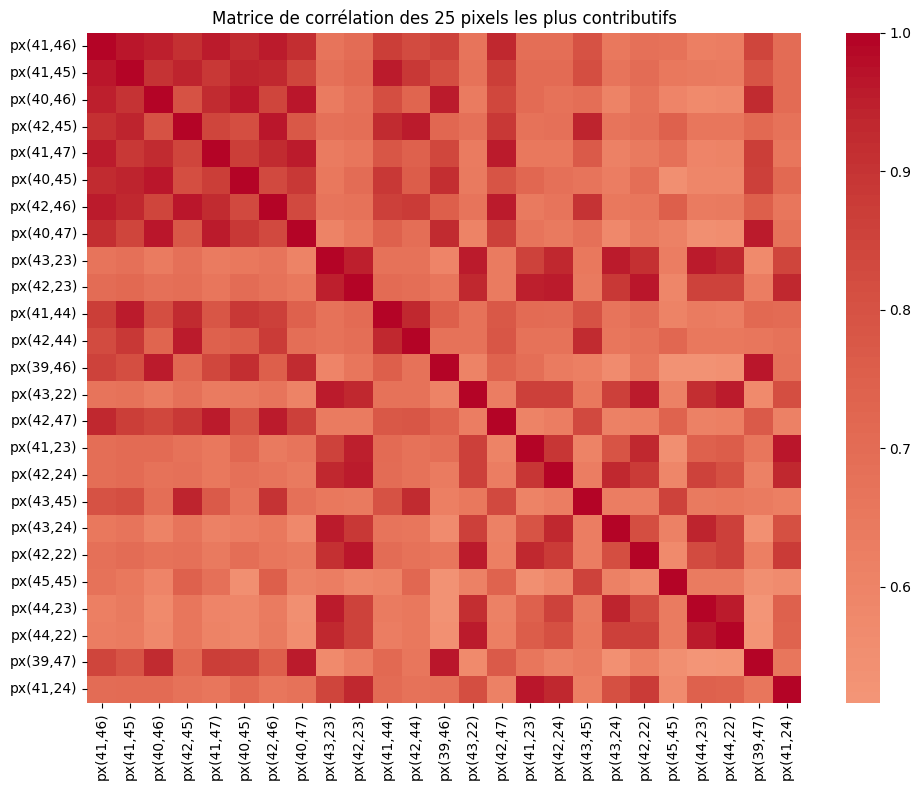

In [65]:
# ============================================================
# 25 bis-F) MATRICE / GRAPHE DE CORRÉLATION DES VARIABLES IMPORTANTES
# ============================================================
# La matrice de corrélation complète des 4096 pixels est très grande.
# Pour une représentation lisible, on prend les pixels les plus contributifs au plan F1-F2.

top_corr_idx = np.argsort(top_score)[::-1][:25]
Z_top = Z_tr[:, top_corr_idx]
R_top = np.corrcoef(Z_top, rowvar=False)
top_labels = [var_labels[i] for i in top_corr_idx]

R_top_df = pd.DataFrame(R_top, index=top_labels, columns=top_labels)
display(R_top_df.round(3).iloc[:10, :10])
R_top_df.to_csv(OUTPUT_DIR / "12_matrice_correlation_top_pixels.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(R_top_df, cmap="coolwarm", center=0, xticklabels=True, yticklabels=True)
plt.title("Matrice de corrélation des 25 pixels les plus contributifs")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_heatmap_correlation_top_pixels.png", dpi=200, bbox_inches="tight")
plt.show()


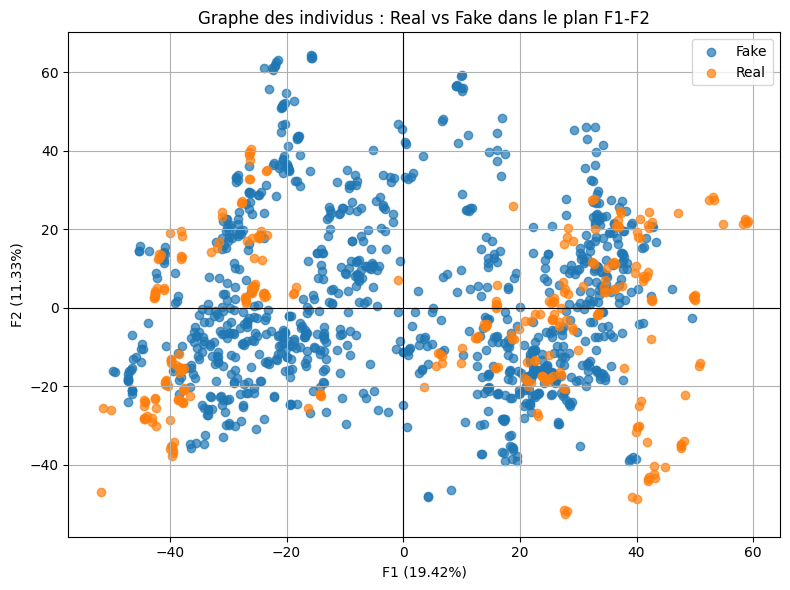

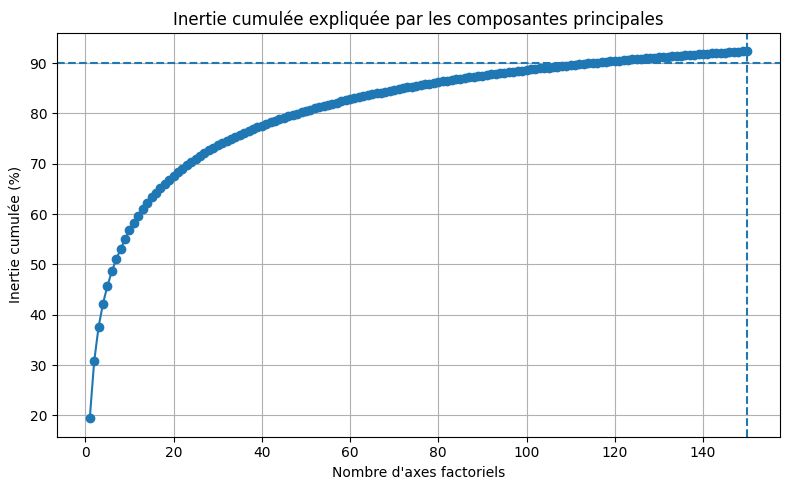

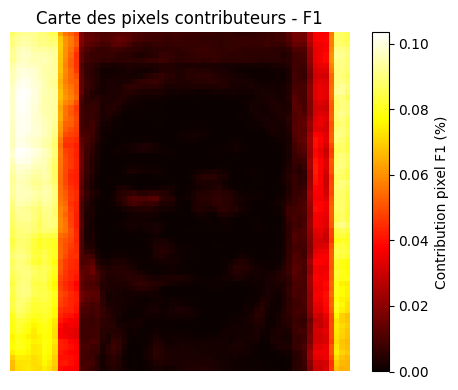

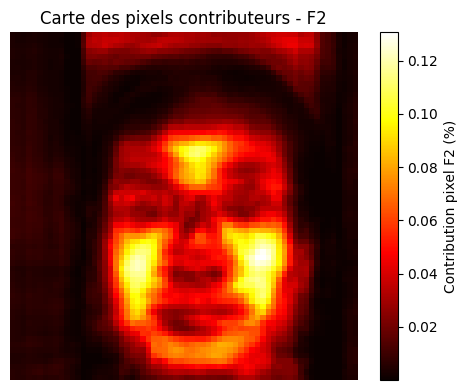

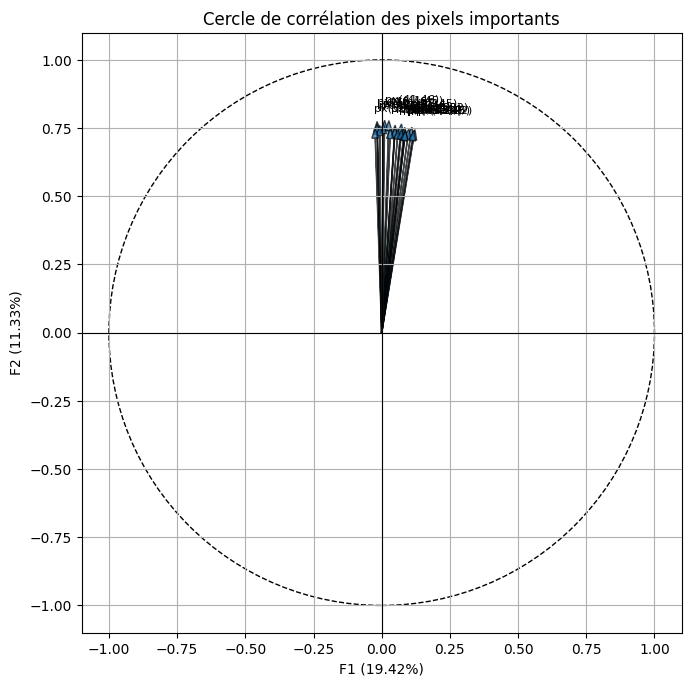

In [ ]:
# ============================================================
# 25 bis-G) FIGURES ACP À EXPORTER POUR LE RAPPORT
# ============================================================

# 1) Graphe des individus F1-F2
plt.figure(figsize=(8, 6))
for lab in np.unique(y_tr):
    idx = (y_tr == lab)
    plt.scatter(C_tr_full[idx, 0], C_tr_full[idx, 1], label=CLASS_NAMES[int(lab)], alpha=0.7)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel(f"F1 ({inertia_ratio[0]*100:.2f}%)")
plt.ylabel(f"F2 ({inertia_ratio[1]*100:.2f}%)")
plt.title("Graphe des individus : Real vs Fake dans le plan F1-F2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_graphe_individus_F1_F2.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) Courbe inertie cumulée
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_inertia)+1), cum_inertia*100, marker="o")
plt.axhline(VARIANCE_TO_KEEP*100, linestyle="--")
plt.axvline(n_selected, linestyle="--")
plt.title("Inertie cumulée expliquée par les composantes principales")
plt.xlabel("Nombre d'axes factoriels")
plt.ylabel("Inertie cumulée (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "14_inertie_cumulee.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) Carte des contributions des pixels pour F1 et F2
def contribution_map(axis=0):
    w, h = IMG_SIZE
    vals = var_contrib[:, axis]
    if MODALITY == "color_depth":
        vals = vals[:w*h]
    return vals.reshape(h, w)

for ax in range(min(2, n_axes_var)):
    plt.figure(figsize=(5, 4))
    plt.imshow(contribution_map(ax), cmap="hot")
    plt.colorbar(label=f"Contribution pixel F{ax+1} (%)")
    plt.title(f"Carte des pixels contributeurs - F{ax+1}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"15_carte_contribution_pixels_F{ax+1}.png", dpi=200, bbox_inches="tight")
    plt.show()

# 4) Cercle de corrélation sauvegardé
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 1, fill=False, linestyle="--")
ax.add_artist(circle)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

for idx in top_idx:
    x = var_coords[idx, 0]
    y = var_coords[idx, 1]
    ax.arrow(0, 0, x, y, head_width=0.025, length_includes_head=True, alpha=0.7)
    ax.text(x*1.08, y*1.08, var_labels[idx], fontsize=8)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal", "box")
ax.set_xlabel(f"F1 ({inertia_ratio[0]*100:.2f}%)")
ax.set_ylabel(f"F2 ({inertia_ratio[1]*100:.2f}%)")
ax.set_title("Cercle de corrélation des pixels importants")
ax.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_cercle_correlation_pixels_importants.png", dpi=200, bbox_inches="tight")
plt.show()


## 29 bis) Décision externe corrigée : seuil Real, zone Incertain et distance au centre ACP

Cette cellule remplace la décision finale brute. Elle reste conforme au cours ACP : l'image externe est projetée dans le même sous-espace factoriel, puis la décision tient compte de la proximité au nuage d'apprentissage et de la confiance Real/Fake.


In [ ]:



def make_test_variants(image_path, img_size):
    
    img_bgr = cv2_read_bgr(image_path)
    if img_bgr is None:
        raise ValueError('Image illisible : ' + str(image_path))

    face_crop, crop_status = crop_face_or_center(img_bgr)
    face_gray = to_gray_float(face_crop, img_size)

    variants = [
        (crop_status, face_gray),
        (crop_status + '_contraste', apply_clahe(face_gray)),
    ]

    return img_bgr, face_crop, variants


def decide_external(mean_fake, mean_real, class_names,
                    real_threshold=0.35,
                    fake_strong_threshold=0.85,
                    uncertainty_margin=0.15,
                    distance_acp=None,
                    distance_threshold=None,
                    use_distance_rejection=True):
    """
    Décision externe ACP-compatible.

    Règles :
    - Si l'image est trop loin du nuage d'apprentissage dans l'espace ACP -> Incertain.
    - Si Fake est très sûr -> Fake.
    - Si Real dépasse un seuil calibré et que Fake n'est pas fortement dominant -> Real.
    - Si les probabilités sont proches -> Incertain.
    - Sinon -> Fake par prudence anti-spoofing.
    """
    fake_name = class_names[0] if isinstance(class_names, dict) else class_names[0]
    real_name = class_names[1] if isinstance(class_names, dict) else class_names[1]

    # 1) Rejet par distance au centre du nuage ACP
    if use_distance_rejection and distance_acp is not None and distance_threshold is not None:
        if distance_acp > distance_threshold:
            return 'Incertain'

    # 2) Fake très sûr : attaque probable
    if mean_fake >= fake_strong_threshold:
        return fake_name

    # 3) Real acceptable : seuil abaissé pour réduire Real -> Fake sur images externes
    # On accepte Real seulement si Fake n'est pas trop dominant.
    if mean_real >= real_threshold and (mean_real - mean_fake) >= -uncertainty_margin:
        return real_name

    # 4) Zone proche : ne pas forcer une mauvaise classe
    if abs(mean_fake - mean_real) < uncertainty_margin:
        return 'Incertain'

    # 5) Par prudence, sinon Fake
    return fake_name


def predict_external_image_acp(image_path, model_path=MODEL_PATH, show_steps=True, verbose=True):
    """
    Prédit Real/Fake pour une image externe.
    On respecte le pipeline du projet : scaler appris -> ACP apprise -> classifieur appris.

    Cette version améliore les vrais visages externes en évitant les décisions Fake faibles :
    - seuil Real calibré ;
    - zone Incertain ;
    - rejet si l'image est trop loin du nuage ACP d'apprentissage.
    """
    bundle = joblib.load(model_path)

    scaler = bundle['scaler']
    pca = bundle['pca']
    model = bundle['model']
    n_selected = bundle['n_selected']
    class_names = bundle['class_names']
    img_size = bundle['img_size']
    modality = bundle.get('modality', 'color')

    # Seuils sauvegardés ou valeurs de secours
    real_threshold = float(bundle.get('real_threshold', bundle.get('external_real_threshold_default', EXTERNAL_REAL_THRESHOLD_DEFAULT)))
    # Si la calibration a donné un seuil trop haut, on garde un seuil externe plus raisonnable.
    real_threshold = min(real_threshold, 0.45)
    fake_strong_threshold = float(bundle.get('external_fake_strong_threshold', EXTERNAL_FAKE_STRONG_THRESHOLD))
    uncertainty_margin = float(bundle.get('external_uncertainty_margin', EXTERNAL_UNCERTAINTY_MARGIN))
    use_distance_rejection = bool(bundle.get('use_acp_distance_rejection', USE_ACP_DISTANCE_REJECTION))
    distance_threshold = bundle.get('external_distance_threshold_acp', None)

    if modality != 'color':
        raise ValueError(
            "Le test upload/caméra est prévu pour MODALITY='color'. "
            "La caméra Colab ne donne pas de depth. Réentraîne le notebook avec MODALITY='color'."
        )

    img_bgr, face_crop, variants = make_test_variants(image_path, img_size)

    if show_steps:
        show_test_preprocessing(image_path, img_bgr, face_crop, variants)

    all_probs = []
    detail_rows = []
    distances = []

    for variant_name, gray_img in variants:
        x = gray_img.flatten().astype(np.float32).reshape(1, -1)

        if x.shape[1] != scaler.n_features_in_:
            raise ValueError(
                f"Dimension incorrecte : image={x.shape[1]}, modèle={scaler.n_features_in_}. "
                "Vérifie IMG_SIZE et MODALITY."
            )

        # Même traitement que dans les TP ACP : centrage-réduction puis projection
        z = scaler.transform(x)
        c_full = pca.transform(z)
        c = c_full[:, :n_selected]
        distance_acp = float(np.sum(c ** 2))
        distances.append(distance_acp)

        pred_variant = int(model.predict(c)[0])

        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(c)[0]
            labels_order = list(model.classes_)
            prob_by_label = {int(lab): float(prob[i]) for i, lab in enumerate(labels_order)}
        else:
            prob_by_label = {0: 0.0, 1: 0.0}
            prob_by_label[pred_variant] = 1.0

        all_probs.append(prob_by_label)
        detail_rows.append({
            'Version testée': variant_name,
            'Prédiction brute': class_names[pred_variant],
            'Proba Fake (%)': prob_by_label.get(0, 0.0) * 100,
            'Proba Real (%)': prob_by_label.get(1, 0.0) * 100,
            'Distance ACP': distance_acp,
        })

    mean_fake = float(np.mean([p.get(0, 0.0) for p in all_probs]))
    mean_real = float(np.mean([p.get(1, 0.0) for p in all_probs]))
    mean_distance_acp = float(np.mean(distances))

    final_prediction = decide_external(
        mean_fake,
        mean_real,
        class_names,
        real_threshold=real_threshold,
        fake_strong_threshold=fake_strong_threshold,
        uncertainty_margin=uncertainty_margin,
        distance_acp=mean_distance_acp,
        distance_threshold=distance_threshold,
        use_distance_rejection=use_distance_rejection,
    )

    details_df = pd.DataFrame(detail_rows)

    if verbose:
        print('=' * 60)
        print('Résultat de la classification après ACP')
        print('=' * 60)
        print('Image :', Path(image_path).name)
        print('Modèle utilisé :', bundle.get('best_model_name', type(model).__name__))
        print('Nombre de composantes ACP utilisées :', n_selected)
        print(f'Probabilité moyenne Fake : {mean_fake*100:.2f}%')
        print(f'Probabilité moyenne Real : {mean_real*100:.2f}%')
        print(f'Distance ACP moyenne : {mean_distance_acp:.4f}')
        if distance_threshold is not None:
            print(f'Seuil distance ACP : {float(distance_threshold):.4f}')
        print(f'Seuil Real utilisé : {real_threshold:.2f}')
        print(f'Seuil Fake fort : {fake_strong_threshold:.2f}')
        print(f'Marge Incertain : {uncertainty_margin:.2f}')
        print('Prédiction finale :', final_prediction)
        print('\nDétails par variante :')
        display(details_df)

    return final_prediction, {'Fake': mean_fake, 'Real': mean_real, 'Distance ACP': mean_distance_acp}, details_df


Mode choisi : upload image


Saving 3 (2).jpg to 3 (2).jpg


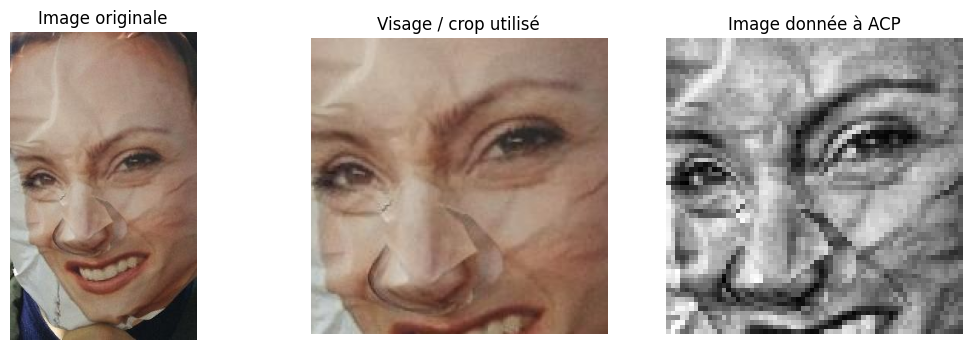

Résultat de la classification après ACP
Image : 3 (2).jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 97.02%
Probabilité moyenne Real : 2.98%
Distance ACP moyenne : 2913.0072
Seuil distance ACP : 6963.1392
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.15
Prédiction finale : Fake

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,crop_central,Fake,98.874554,1.125446,2399.104736
1,crop_central_contraste,Fake,95.167535,4.832465,3426.909668


In [75]:
# ============================================================
# 31) LANCER LE TEST FINAL
# ============================================================
# Choisir seulement un mode : 'upload' ou 'camera'

TEST_MODE = 'upload'   # change en 'camera' pour utiliser la caméra Colab

prediction, probabilities, details = run_interactive_test(TEST_MODE)


Mode choisi : upload image


Saving image.jpg to image.jpg


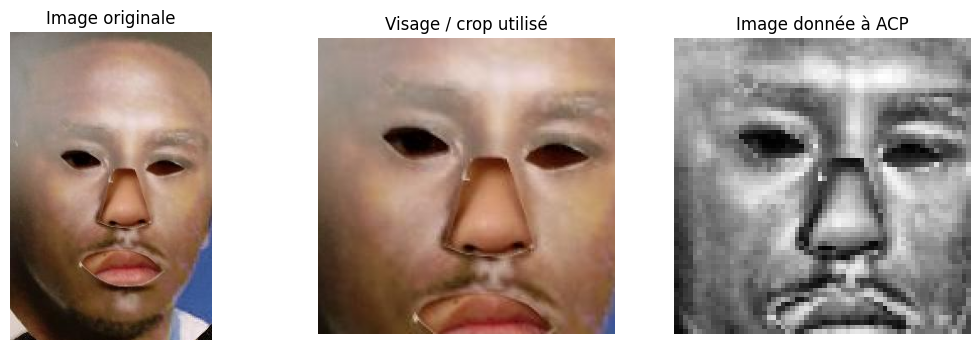

Résultat de la classification après ACP
Image : image.jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 97.51%
Probabilité moyenne Real : 2.49%
Distance ACP moyenne : 3164.8101
Seuil distance ACP : 6963.1392
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.15
Prédiction finale : Fake

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,crop_central,Fake,98.991329,1.008671,2877.195312
1,crop_central_contraste,Fake,96.018789,3.981211,3452.424805


In [76]:
# ============================================================
# 31) LANCER LE TEST FINAL
# ============================================================
# Choisir seulement un mode : 'upload' ou 'camera'

TEST_MODE = 'upload'   # change en 'camera' pour utiliser la caméra Colab

prediction, probabilities, details = run_interactive_test(TEST_MODE)


Mode choisi : upload image


Saving download.jpg to download.jpg


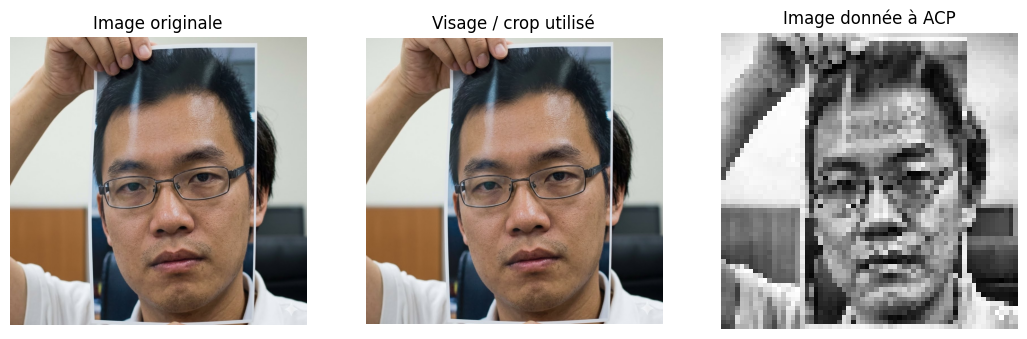

Résultat de la classification après ACP
Image : download.jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 95.95%
Probabilité moyenne Real : 4.05%
Distance ACP moyenne : 4883.9158
Seuil distance ACP : 6963.1392
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.15
Prédiction finale : Fake

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,visage_detecte,Fake,99.533175,0.466825,4389.864258
1,visage_detecte_contraste,Fake,92.363920,7.636080,5377.967285


In [77]:
# ============================================================
# 31) LANCER LE TEST FINAL
# ============================================================
# Choisir seulement un mode : 'upload' ou 'camera'

TEST_MODE = 'upload'   # change en 'camera' pour utiliser la caméra Colab

prediction, probabilities, details = run_interactive_test(TEST_MODE)


Mode choisi : upload image


Saving 312911723_442153011360862_4013659178066409617_n.jpg to 312911723_442153011360862_4013659178066409617_n.jpg


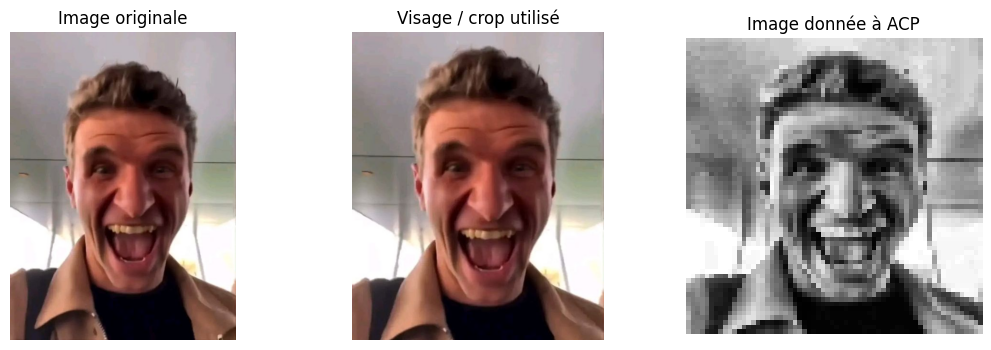

Résultat de la classification après ACP
Image : 312911723_442153011360862_4013659178066409617_n.jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 0.14%
Probabilité moyenne Real : 99.86%
Distance ACP moyenne : 7660.2195
Seuil distance ACP : 6963.1392
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.15
Prédiction finale : Incertain

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,visage_detecte,Real,0.282105,99.717895,8037.724609
1,visage_detecte_contraste,Real,0.000951,99.999049,7282.714355


In [78]:
# ============================================================
# 31) LANCER LE TEST FINAL
# ============================================================
# Choisir seulement un mode : 'upload' ou 'camera'

TEST_MODE = 'upload'   # change en 'camera' pour utiliser la caméra Colab

prediction, probabilities, details = run_interactive_test(TEST_MODE)


Mode choisi : caméra Google Colab


<IPython.core.display.Javascript object>

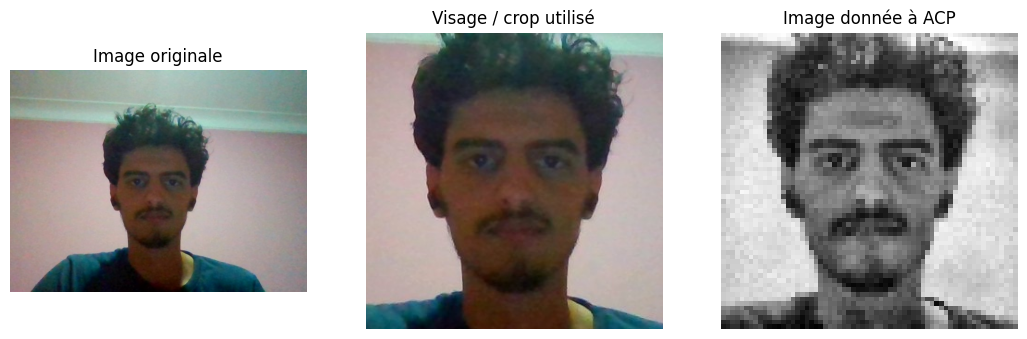

Résultat de la classification après ACP
Image : photo_camera_colab.jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 0.89%
Probabilité moyenne Real : 99.11%
Distance ACP moyenne : 6744.8442
Seuil distance ACP : 6963.1392
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.15
Prédiction finale : Real

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,visage_detecte,Real,1.447710,98.552290,7359.204102
1,visage_detecte_contraste,Real,0.323164,99.676836,6130.484375


In [83]:
# ============================================================
# 31) LANCER LE TEST FINAL
# ============================================================
# Choisir seulement un mode : 'upload' ou 'camera'

TEST_MODE = 'camera'   # change en 'camera' pour utiliser la caméra Colab

prediction, probabilities, details = run_interactive_test(TEST_MODE)


Mode choisi : upload image


Saving 315369_10150946815093434_1654012338_n.jpg to 315369_10150946815093434_1654012338_n.jpg


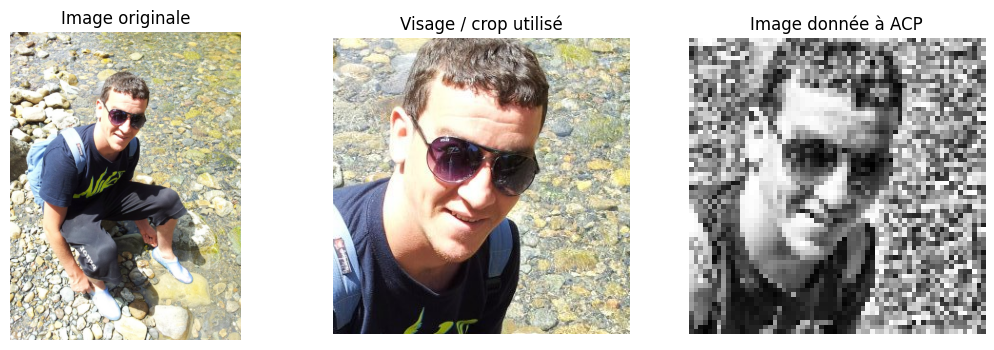

Résultat de la classification après ACP
Image : 315369_10150946815093434_1654012338_n.jpg
Modèle utilisé : SVM RBF équilibré
Nombre de composantes ACP utilisées : 150
Probabilité moyenne Fake : 0.44%
Probabilité moyenne Real : 99.56%
Distance ACP moyenne : 6625.6702
Seuil distance ACP : 6963.1392
Seuil Real utilisé : 0.20
Seuil Fake fort : 0.85
Marge Incertain : 0.15
Prédiction finale : Real

Détails par variante :


,Version testée,Prédiction brute,Proba Fake (%),Proba Real (%),Distance ACP
0,visage_detecte,Real,0.357758,99.642242,8532.737305
1,visage_detecte_contraste,Real,0.513799,99.486201,4718.603027


In [80]:
# ============================================================
# 31) LANCER LE TEST FINAL
# ============================================================
# Choisir seulement un mode : 'upload' ou 'camera'

TEST_MODE = 'upload'   # change en 'camera' pour utiliser la caméra Colab

prediction, probabilities, details = run_interactive_test(TEST_MODE)
